# cNLP4QoL — LLM-Based QoL Tagging with PDSQI-9 Summaries  
**v4 — with Step 6: Gold-Standard Evaluation**
## Colab Notebook (ICHI 2026)

**Research question:** How does representation choice (raw conversation vs. patient-perspective vs. clinician-perspective summary) affect the transfer of wellness-dimension prediction from social-media text to mental-health conversations?

**Hypothesis:** Summarization is not just compression — it acts as a domain-bridging transformation.

**Pipeline**
1. Setup — install dependencies, mount Drive
2. Step 0 — load & standardise MultiWD, Kaggle Therapist, MentalChat16K
3. Step 1 — PDSQI-9-compliant patient & clinician summary generation
4. Step 1b — PDSQI-9 LLM-as-a-Judge validation
5. **Step 2 — LLM QoL tagging on MultiWD (GPT-5.4 nano + open-source Qwen/Llama)**
6. **Step 3 — External LLM inference on Kaggle + MentalChat**
7. **Step 4 — Representation comparison: prevalence, agreement, domain drift**

> **QoL domains**: Spiritual · Physical · Intellectual · Social · Vocational · Emotional
> **Reference**: PDSQI-9 — Croxford et al., JAMIA 2025


## Step 0a — Install Dependencies

In [1]:
!pip -q install transformers datasets accelerate sentencepiece bitsandbytes \
    kagglehub pandas openpyxl scikit-learn torch tqdm openai \
    matplotlib seaborn peft trl contextgem
print('Dependencies installed')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.5/251.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.

## Step 0b — Mount Google Drive

In [2]:
from google.colab import drive
import os
!rm -rf /content/drive
drive.mount('/content/drive', force_remount=True)
DRIVE_DIR = '/content/drive/MyDrive/Google Colab Notebooks/Datasets/'
os.makedirs(DRIVE_DIR, exist_ok=True)
%cd {DRIVE_DIR}
print('Working dir:', os.getcwd())


Mounted at /content/drive
/content/drive/MyDrive/Google Colab Notebooks/Datasets
Working dir: /content/drive/MyDrive/Google Colab Notebooks/Datasets


## Step 0c — Paths and Constants

In [3]:
import os

DRIVE_ROOT       = '/content/drive/MyDrive/Google Colab Notebooks/Datasets'
FEW_SHOT_PATH    = f'{DRIVE_ROOT}/few_shot_dataset.txt'
VAL_MAIN_FILE    = f'{DRIVE_ROOT}/Val_Datasets.xlsx'
INPUT_DIR        = f'{DRIVE_ROOT}/FullDataset_input_derivedfrom_new_summary_datasets_v2'
OUTPUT_DIR       = f'{DRIVE_ROOT}/FullDataset_output_derivedfrom_new_summary_outputs_v2'
LLM_RESULTS_DIR  = f'{DRIVE_ROOT}/FullDataset_results_derivedfrom_llm_qol_results_v2'

for d in [INPUT_DIR, OUTPUT_DIR, LLM_RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

MULTIWD_SHEET    = 'multiwd50'
MENTALCHAT_SHEET = 'mc50'
KAGGLE_SHEET     = 'kaggle11'

LABEL_COLS = ['Spiritual','Physical','Intellectual','Social','Vocational','Emotional']

print('Paths configured. Output dir:', OUTPUT_DIR)


Paths configured. Output dir: /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_output_derivedfrom_new_summary_outputs_v2


## Step 0d — Standardise Datasets

In [4]:
import pandas as pd

def standardize_text_column(df, name):
    df = df.copy(); target_col = 'text'; src = None
    SINGLE_COLS = ['text','conversation','dialogue','dialog','utterance','content','transcript','message','messages']
    PAIR_COLS   = [('patient','therapist'),('patient_text','therapist_text'),
                   ('user','assistant'),('speaker1','speaker2'),
                   ('input','response'),('question','answer')]
    if target_col in df.columns:
        src = 'existing_text_column'
    else:
        for c in SINGLE_COLS:
            if c in df.columns:
                df[target_col] = df[c].fillna('').astype(str); src = c; break
        if target_col not in df.columns:
            for c1,c2 in PAIR_COLS:
                if c1 in df.columns and c2 in df.columns:
                    df[target_col] = 'Patient: ' + df[c1].fillna('').astype(str) + '\nTherapist: ' + df[c2].fillna('').astype(str)
                    src = f'{c1}+{c2}'; break
        if target_col not in df.columns:
            obj_cols = [c for c in df.columns if df[c].dtype == object]
            df[target_col] = df[obj_cols].fillna('').astype(str).agg(' '.join, axis=1)
            src = 'ALL_OBJECT_COLUMNS'
    df[target_col] = df[target_col].fillna('').astype(str).str.strip()
    df = df[df[target_col] != ''].reset_index(drop=True)
    print(f'{name}: source={src}, rows={len(df)}')
    return df, src

print('Loading MultiWD...')
multiwd_df, _ = standardize_text_column(pd.read_excel(VAL_MAIN_FILE, sheet_name=MULTIWD_SHEET, engine='openpyxl'), 'MultiWD')
multiwd_df.to_csv(f'{INPUT_DIR}/multiwd_standardized.csv', index=False)

print('Loading Kaggle...')
kaggle_df, _ = standardize_text_column(pd.read_excel(VAL_MAIN_FILE, sheet_name=KAGGLE_SHEET, engine='openpyxl'), 'Kaggle')
kaggle_df.to_csv(f'{INPUT_DIR}/kaggle_therapist_standardized.csv', index=False)

print('Loading MentalChat...')
mc_df, _ = standardize_text_column(pd.read_excel(VAL_MAIN_FILE, sheet_name=MENTALCHAT_SHEET, engine='openpyxl'), 'MentalChat16K')
mc_df.to_csv(f'{INPUT_DIR}/mentalchat_standardized.csv', index=False)

print('Standardized datasets saved to', INPUT_DIR)


Loading MultiWD...
MultiWD: source=ALL_OBJECT_COLUMNS, rows=50
Loading Kaggle...
Kaggle: source=ALL_OBJECT_COLUMNS, rows=11
Loading MentalChat...
MentalChat16K: source=ALL_OBJECT_COLUMNS, rows=50
Standardized datasets saved to /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_input_derivedfrom_new_summary_datasets_v2


## Step 1 — PDSQI-9-Compliant Summary Generation

Generates ONE patient-perspective and ONE clinician-perspective summary per conversation row.

| PDSQI-9 attribute | How enforced |
|---|---|
| Accurate | Ground every claim in transcript |
| Cited | `(Source: turn N)` tag after each sentence |
| Thorough | Address every identified QoL domain |
| Useful | Role-specific register |
| Organized | `[Domain]` sentence tags |
| Comprehensible | Explicit language register constraint |
| Succinct | 4-7 sentences |
| Synthesized | Merge across turns |
| Non-Stigmatizing | Person-first, recovery-oriented |


In [5]:
import torch, os, re, json
import pandas as pd
from tqdm import tqdm

assert torch.cuda.is_available(), 'Enable GPU in Runtime settings'
print('GPU:', torch.cuda.get_device_name(0))

USE_VLLM        = False
VLLM_API_URL    = 'http://localhost:8000/v1'
HF_MODEL_NAME   = 'Qwen/Qwen2.5-3B-Instruct'
VLLM_MODEL_NAME = 'meta-llama/Llama-3.1-8B-Instruct'
MAX_NEW_TOKENS  = 400
TEMPERATURE     = 0.05
TEXT_COL        = 'text'

DATASETS = {
    'multiwd':    f'{INPUT_DIR}/multiwd_standardized.csv',
    'kaggle':     f'{INPUT_DIR}/kaggle_therapist_standardized.csv',
    'mentalchat': f'{INPUT_DIR}/mentalchat_standardized.csv',
}

DOMAIN_NORM = {
    'Physical Well-Being':'Physical','Emotional Well-Being':'Emotional',
    'Social Functioning':'Social','Intellectual State':'Intellectual',
    'Spiritual Perspective':'Spiritual','Vocational':'Vocational',
    'Physical':'Physical','Emotional':'Emotional','Social':'Social',
    'Intellectual':'Intellectual','Spiritual':'Spiritual',
}
def normalise_domains(raw_domains):
    out = []
    for d in raw_domains:
        n = DOMAIN_NORM.get(str(d).strip())
        if n and n not in out: out.append(n)
    return out

def load_few_shot_tagging_examples(path, n=120):
    if not os.path.exists(path):
        print(f'[ERROR] {path} not found'); return []
    with open(path,'r',encoding='utf-8') as f: raw = f.read()
    pattern = re.compile(r'\[PATIENT\]:\s*"(.*?)"\s*\nResponse:\s*(\{.*?\})', re.DOTALL)
    matches = pattern.findall(raw)
    print(f'Regex matches: {len(matches)}')
    examples = []
    for text, resp_str in matches:
        try:
            resp = json.loads(resp_str)
            examples.append({'text': text.strip(), 'domains': normalise_domains(resp.get('qol_domains', []))})
            if len(examples) >= n: break
        except Exception: continue
    return examples

FEW_SHOT_EXAMPLES = load_few_shot_tagging_examples(FEW_SHOT_PATH, n=120)
print(f'Loaded few-shot examples: {len(FEW_SHOT_EXAMPLES)}')


GPU: Tesla T4
Regex matches: 119
Loaded few-shot examples: 119


In [6]:
def build_tagging_prompt(text):
    domain_list = 'Spiritual, Physical, Intellectual, Social, Vocational, Emotional'
    shots = ''
    for ex in FEW_SHOT_EXAMPLES[:5]:
        shots += f'\nText:\n"{ex["text"][:300]}"\nDomains: {json.dumps(ex["domains"])}\n'
    return (
        'You are a QoL domain classifier for clinical text.\n\n'
        'Identify which Quality of Life domains are expressed in the text.\n'
        'The text may be a patient monologue OR a patient-therapist dialogue.\n'
        'A domain is present if ANY speaker\'s turn provides evidence for it.\n\n'
        f'DOMAINS: {domain_list}\n\n'
        f'FEW-SHOT EXAMPLES:\n{shots}\n'
        f'Text:\n"""{text}"""\n\n'
        'Return ONLY valid JSON: {"qol_domains": ["domain1", ...]}'
    )

def parse_domains(raw_response):
    try:
        m = re.search(r'\{.*\}', raw_response, re.DOTALL)
        if m:
            d = json.loads(m.group())
            return normalise_domains(d.get('qol_domains', []))
    except Exception: pass
    return []

DIALOGUE_FEW_SHOT_PATIENT = (
    '--- EXAMPLE (FIRST-PERSON, PATIENT VOICE) ---\n'
    'Transcript:\n"Patient: I haven\'t been sleeping well; I keep worrying about losing my job.\n'
    ' Therapist: Are you still connected with your family?\n'
    ' Patient: Not really. I feel like a burden to them."\n\n'
    'Identified domains: Physical, Emotional, Social, Vocational\n\n'
    'Patient-perspective summary (written BY the patient, in first person):\n'
    '[Physical] I haven\'t been sleeping well lately, and the restlessness is wearing me down. (Source: patient turn 1)\n'
    '[Vocational] I can\'t stop worrying that I might lose my job, and that fear sits with me all day. (Source: patient turn 1)\n'
    '[Emotional] I feel anxious and weighed down by a constant sense that I am a burden to the people I love. (Source: patient turns 1, 3)\n'
    '[Social] I don\'t feel close to my family right now \u2014 I keep pulling back because I think I\'m draining them. (Source: patient turn 3)\n'
    '--- END EXAMPLE ---'
)

DIALOGUE_FEW_SHOT_CLINICIAN = (
    '--- EXAMPLE ---\n'
    'Transcript:\n"Patient: I haven\'t been sleeping well; I keep worrying about losing my job.\n'
    ' Therapist: Are you still connected with my family?\n'
    ' Patient: Not really. I feel like a burden to them."\n\n'
    'Identified domains: Physical, Emotional, Social, Vocational\n\n'
    'Clinician-perspective summary:\n'
    '[Physical] Patient reports significant sleep disturbance. (Source: turn 1)\n'
    '[Vocational] Patient endorses persistent occupational worry. (Source: turn 1)\n'
    '[Emotional] Patient presents with anxiety and self-directed shame. (Source: turns 1, 3)\n'
    '[Social] Patient indicates diminished family connectedness. (Source: turn 3)\n'
    '--- END EXAMPLE ---'
)

def build_patient_prompt(text, domains):
    domain_str = ', '.join(domains) if domains else 'Spiritual, Physical, Intellectual, Social, Vocational, Emotional'
    return (
        'ROLE: You ARE the patient. You are writing a short personal reflection \u2014 like a diary entry \u2014 '
        'about what was on your mind during today\'s therapy session. You are NOT a clinician, '
        'NOT an observer, and NOT summarizing someone else. Write as yourself.\n\n'
        'VOICE REQUIREMENTS (STRICT):\n'
        '- Write in FIRST PERSON only.\n'
        '- Use "I", "me", "my", "mine", "myself".\n'
        '- NEVER use "the patient", "she", "he", "they", "this individual", "the client", '
        '"the speaker", or any third-person reference to yourself.\n'
        '- NEVER use clinical reporting verbs such as "reports", "expresses", "exhibits", '
        '"presents with", "endorses", "describes feeling", "demonstrates", "states that".\n'
        '- Speak directly: instead of "The patient feels anxious", write "I feel anxious".\n'
        '- Tone: honest, plain, empathetic toward yourself. Like talking to your therapist or your journal.\n\n'
        'PDSQI-9 RULES:\n'
        '1. ACCURATE - Ground every claim in the transcript.\n'
        '2. CITED - Add (Source: patient turn <N>) after each sentence.\n'
        '3. THOROUGH - Cover EVERY identified domain below.\n'
        '4. USEFUL - First person, empathetic, plain language.\n'
        '5. ORGANIZED - [Domain] tag at the start of each sentence.\n'
        '6. COMPREHENSIBLE - Your own voice. No medical or clinical jargon.\n'
        '7. SUCCINCT - 4-7 sentences total.\n'
        '8. SYNTHESIZED - Merge insights across turns; do not copy verbatim.\n'
        '9. NON-STIGMATIZING - Use person-first language: focus on the person, not the condition. Avoid diagnostic labels (e.g., "depression", "anxiety disorder").\n\n'
        f'IDENTIFIED QoL DOMAINS (must all be covered): {domain_str}\n\n'
        f'{DIALOGUE_FEW_SHOT_PATIENT}\n\n'
        f'Transcript:\n"""{text}"""\n\n'
        'Before you finish, silently check: every sentence must begin with "[Domain]" and use "I/me/my". '
        'If any sentence refers to "the patient", "she", "he", or "they", rewrite it in first person.\n\n'
        'Patient-perspective summary (in MY own voice, first person):'
    )


def build_clinician_prompt(text, domains):
    domain_str = ', '.join(domains) if domains else 'Spiritual, Physical, Intellectual, Social, Vocational, Emotional'
    return (
        'You are an expert clinical scribe preparing a QoL-focused note.\n\n'
        'TASK: Write a CLINICIAN-PERSPECTIVE summary.\n\n'
        'PDSQI-9 RULES:\n'
        '1. ACCURATE - Every observation supported by transcript.\n'
        '2. CITED - Add (Source: turn <N>) after each sentence.\n'
        '3. THOROUGH - Document ALL identified domains below.\n'
        '4. USEFUL - Third-person clinical language.\n'
        '5. ORGANIZED - [Domain] tag starting each sentence.\n'
        '6. COMPREHENSIBLE - Standard clinical terminology.\n'
        '7. SUCCINCT - 4-7 sentences maximum.\n'
        '8. SYNTHESIZED - Integrate multiple turns into coherent observations.\n'
        '9. NON-STIGMATIZING - Use person-first and recovery-oriented language. Focus on the individual, not the condition. For example, instead of "the anxious patient", use "the patient experiencing anxiety".\n\n'
        f'IDENTIFIED QoL DOMAINS (must all be covered): {domain_str}\n\n'
        f'{DIALOGUE_FEW_SHOT_CLINICIAN}\n\n'
        f'Transcript:\n"""{text}"""\n\n'
        'Clinician-perspective summary:'
    )

# ---- First-person safety net ----
THIRD_PERSON_PATTERNS = [
    r'\bthe patient\b', r'\bthe client\b', r'\bthis individual\b',
    r'\bshe\b', r'\bhe\b', r'\bthey\b(?!\'re|\'ve|\'ll)',
    r'\bher\b', r'\bhis\b', r'\btheir\b',
    r'\b(reports|expresses|exhibits|endorses|presents with|describes feeling|demonstrates)\b',
]

def is_first_person(summary_text):
    flags = []
    for pat in THIRD_PERSON_PATTERNS:
        if re.search(pat, summary_text, flags=re.IGNORECASE):
            flags.append(pat)
    return (len(flags) == 0), flags

def regenerate_if_third_person(text, domains, max_retries=2):
    out = call_llm(build_patient_prompt(text, domains), VLLM_SYS_SUM)
    for _ in range(max_retries):
        ok, flags = is_first_person(out)
        if ok: return out, True
        out = call_llm(build_patient_prompt(text, domains), VLLM_SYS_SUM)
    ok, _ = is_first_person(out)
    return out, ok


In [7]:
VLLM_SYS_TAG = 'You are a QoL domain classifier. Return ONLY valid JSON.'
VLLM_SYS_SUM = 'You are a PDSQI-9-compliant clinical documentation assistant.'

if USE_VLLM:
    from openai import OpenAI
    _client = OpenAI(base_url=VLLM_API_URL, api_key='openai_api_key')
    def call_llm(prompt, system_msg, max_tokens=MAX_NEW_TOKENS, temp=TEMPERATURE):
        try:
            resp = _client.chat.completions.create(
                model=VLLM_MODEL_NAME,
                messages=[{'role':'system','content':system_msg},{'role':'user','content':prompt}],
                temperature=temp, max_tokens=max_tokens)
            return resp.choices[0].message.content.strip()
        except Exception as e: return f'[ERROR] {e}'
else:
    from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline as hf_pipeline
    print(f'Loading {HF_MODEL_NAME}...')
    _tok = AutoTokenizer.from_pretrained(HF_MODEL_NAME)
    _mdl = AutoModelForCausalLM.from_pretrained(HF_MODEL_NAME, dtype=torch.float16, device_map='auto')
    _gen = hf_pipeline('text-generation', model=_mdl, tokenizer=_tok)
    def call_llm(prompt, system_msg, max_tokens=MAX_NEW_TOKENS, temp=TEMPERATURE):
        try:
            messages = [{'role':'system','content':system_msg},{'role':'user','content':prompt}]
            formatted = _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            out = _gen(formatted, max_new_tokens=max_tokens, do_sample=False,
                       return_full_text=False, pad_token_id=_tok.eos_token_id)
            return out[0]['generated_text'].strip()
        except Exception as e: return f'[ERROR] {e}'


Loading Qwen/Qwen2.5-3B-Instruct...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

**Generating Summaries!**

In [ ]:
### this is a long process.. generating summaries across all 3 datasets 50 summaries each for for patient and clinician respectively

import concurrent.futures

def process_dataset(ds_name, file_path):
    if not os.path.exists(file_path):
        print(f'[SKIP] {file_path} missing')
        return

    print(f'\n--- Starting thread for: {ds_name.upper()} ---')
    df = pd.read_csv(file_path)
    df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)
    df = df[df[TEXT_COL].str.strip() != ''].reset_index(drop=True)

    tagged_domains, pat_sum, clin_sum = [], [], []
    # Note: Using position arguments in tqdm may help avoid visual overlapping in multithreaded environments
    for text in tqdm(df[TEXT_COL], desc=ds_name, leave=True):
        domains = parse_domains(call_llm(build_tagging_prompt(text), VLLM_SYS_TAG, max_tokens=150, temp=0.0))
        tagged_domains.append(domains)
        _pat, _pat_ok = regenerate_if_third_person(text, domains)
        pat_sum.append(_pat)
        clin_sum.append(call_llm(build_clinician_prompt(text, domains), VLLM_SYS_SUM))

    df['predicted_domains'] = [json.dumps(d) for d in tagged_domains]
    df.to_csv(f'{OUTPUT_DIR}/{ds_name}_raw.csv', index=False)

    df_p = df.copy(); df_p[TEXT_COL] = pat_sum
    df_p.to_csv(f'{OUTPUT_DIR}/{ds_name}_patient_summary.csv', index=False)

    df_c = df.copy(); df_c[TEXT_COL] = clin_sum
    df_c.to_csv(f'{OUTPUT_DIR}/{ds_name}_clinician_summary.csv', index=False)

    print(f'\n  [DONE] Saved {len(df)} rows for {ds_name}')

# Run datasets in parallel using a ThreadPool
with concurrent.futures.ThreadPoolExecutor(max_workers=len(DATASETS)) as executor:
    futures = [executor.submit(process_dataset, name, path) for name, path in DATASETS.items()]
    concurrent.futures.wait(futures)

print('\nSummary generation complete across all parallel threads.')


--- Starting thread for: MULTIWD ---
--- Starting thread for: KAGGLE ---


--- Starting thread for: MENTALCHAT ---



kaggle:   0%|          | 0/11 [00:00<?, ?it/s]

mentalchat:   0%|          | 0/50 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` wil


  [DONE] Saved 11 rows for kaggle


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


mentalchat:  34%|███▍      | 17/50 [28:32<44:33, 81.01s/it][transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the


  [DONE] Saved 50 rows for multiwd


[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


mentalchat:  84%|████████▍ | 42/50 [57:11<09:36, 72.02s/it][transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the


  [DONE] Saved 50 rows for mentalchat

Summary generation complete across all parallel threads.


## Step 1b — PDSQI-9 LLM-as-a-Judge Validation

Each summary is scored on all 9 PDSQI-9 attributes.
A row passes when all Likert scores ≥ 3 and Stigmatizing == 1.


In [ ]:
# from tqdm import tqdm
# import os, re, json
# import pandas as pd

# # Ensure call_llm is available in this cell's scope if not already
# if 'call_llm' not in globals():
#     from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline as hf_pipeline
#     import torch
#     MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'
#     #MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'
#     print(f'Reloading {MODEL_ID} for validation...')
#     _tok = AutoTokenizer.from_pretrained(MODEL_ID)
#     _mdl = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float16, device_map='auto')
#     _gen = hf_pipeline('text-generation', model=_mdl, tokenizer=_tok)
#     def call_llm(prompt, system_msg, max_tokens=400, temp=0.05):
#         try:
#             messages = [{'role':'system','content':system_msg},{'role':'user','content':prompt}]
#             formatted = _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#             out = _gen(formatted, max_new_tokens=max_tokens, do_sample=False,
#                        return_full_text=False, pad_token_id=_tok.eos_token_id)
#             return out[0]['generated_text'].strip()
#         except Exception as e: return f'[ERROR] {e}'

In [ ]:
###### POTENTIAL ALTERNATE:
# import torch
# from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# # Configuration for optimal T4 Performance
# JUDGE_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# print(f"Initializing {JUDGE_MODEL_ID} on T4 GPU...")

# tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)

# # Using float16 + device_map='auto' to ensure the 8B model fits in 16GB VRAM
# model = AutoModelForCausalLM.from_pretrained(
#     JUDGE_MODEL_ID,
#     torch_dtype=torch.float16,
#     device_map="auto",
#     trust_remote_code=True
# )

# judge_pipeline = pipeline(
#     "text-generation",
#     model=model,
#     tokenizer=tokenizer,
# )

# print("Judge Model Ready. Memory usage:", torch.cuda.memory_allocated(0) / 1024**3, "GB")

In [8]:
from tqdm import tqdm
import os, re, json
import pandas as pd

# Ensure call_llm is available in this cell's scope using Llama-3.1-8B
if 'call_llm' not in globals():
    from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline as hf_pipeline
    import torch

    # Switching to Llama-3.1-8B-Instruct as requested
    MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'

    print(f'Reloading {MODEL_ID} for validation...')
    _tok = AutoTokenizer.from_pretrained(MODEL_ID)

    # Using float16 and device_map='auto' is critical for fitting 8B params in 16GB VRAM
    _mdl = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto',
        trust_remote_code=True
    )

    _gen = hf_pipeline('text-generation', model=_mdl, tokenizer=_tok)

    def call_llm(prompt, system_msg, max_tokens=400, temp=0.05):
        try:
            messages = [
                {'role': 'system', 'content': system_msg},
                {'role': 'user', 'content': prompt}
            ]
            formatted = _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            out = _gen(
                formatted,
                max_new_tokens=max_tokens,
                do_sample=False,
                return_full_text=False,
                pad_token_id=_tok.eos_token_id,
                clean_up_tokenization_spaces=True
            )
            return out[0]['generated_text'].strip()
        except Exception as e:
            return f'[ERROR] {e}'

In [9]:
## ran additional analysis here: https://colab.research.google.com/drive/1wRr6m1U6InrXEbLdTvX6B0_NYPO7310Q#scrollTo=ecea6476&line=1&uniqifier=1


VALIDATION_DIR = f'{OUTPUT_DIR}/pdsqi9_validation'
os.makedirs(VALIDATION_DIR, exist_ok=True)
VALIDATE_SAMPLE_N = 50

LIKERT_COLS = ["Accurate","Cited","Thorough","Useful","Organized",
               "Comprehensible","Succinct","Synthesized"]

def score_pdsqi9(transcript, text, perspective="patient"):
    """Score a summary against PDSQI-9 using strict binary enforcement for Rule 9."""
    is_patient = perspective == "patient"
    likert_rules = {
        "Accurate":       "Is every claim grounded in the RAW TRANSCRIPT? (1=Poor, 5=Excellent)",
        "Cited":          "Does every sentence have a (Source: turn N) citation matching the RAW TRANSCRIPT? (1-5)",
        "Thorough":       "Are all QoL domains covered with evidence? (1-5)",
        "Useful":         ("First-person plain language?" if is_patient else "Third-person clinical language?") + " (1-5)",
        "Organized":      "Does every sentence start with a [Domain] tag? (1-5)",
        "Comprehensible": ("Jargon avoided?" if is_patient else "Clinical terminology correct?") + " (1-5)",
        "Succinct":       "Is it 4-7 sentences? (1-5)",
        "Synthesized":    "Are turns merged rather than copied verbatim? (1-5)",
    }

    prompt = (
        f"### TASK: EVALUATE THIS {perspective.upper()}-PERSPECTIVE SUMMARY AGAINST THE SOURCE TRANSCRIPT.\n\n"
        "### SCORING RULES (LIKERT 1-5):\n"
        + "\n".join(f"- {k}: {v}" for k, v in likert_rules.items())
        + "\n\n### SCORING RULES (STRICT BINARY 0 OR 1):\n"
        "- Non_Stigmatizing: Does the text strictly follow Rule 9 (Person-first, recovery-oriented language)? "
        "Return 1 if it PASSES (is non-stigmatizing). Return 0 if it FAILS (contains stigmatizing labels).\n\n"
        "### CONSTRAINT: YOU MUST RETURN ONLY VALID JSON. DO NOT EXPLAIN.\n"
        "### JSON TEMPLATE:\n"
        "{\n"
        "  \"Accurate\": <1-5>, \"Cited\": <1-5>, \"Thorough\": <1-5>, \"Useful\": <1-5>,\n"
        "  \"Organized\": <1-5>, \"Comprehensible\": <1-5>, \"Succinct\": <1-5>, \"Synthesized\": <1-5>,\n"
        "  \"Non_Stigmatizing\": <0 or 1>\n"
        "}\n\n"
        f"TRANSCRIPT:\n\"\"\"{transcript}\"\"\"\n\n"
        f"SUMMARY TO EVALUATE:\n\"\"\"{text}\"\"\"\n"
        "JSON OUTPUT:"
    )

    raw = call_llm(prompt, system_msg="You are a clinical NLP evaluator. Return ONLY valid JSON. Rule 9 (Non_Stigmatizing) must be strictly 0 or 1.")

    try:
        m = re.search(r"\{.*?\}", raw, re.DOTALL)
        if m:
            d = json.loads(m.group())
            scores = {k: float(d.get(k, 2.50)) for k in LIKERT_COLS}
            # Force binary parse
            val = d.get("Non_Stigmatizing", 1)
            scores["Non_Stigmatizing"] = 1 if str(val) == "1" or val == 1 or float(val) >= 2.5 else 0.0
            return scores
    except Exception:
        pass

    defaults = {k: 2.5 for k in LIKERT_COLS}
    defaults["Non_Stigmatizing"] = 1.0
    return defaults

In [ ]:
### this is also a long process.. validating all summaries

import concurrent.futures
from tqdm import tqdm
import pandas as pd
import os

def process_validation(ds_name, perspective):
    raw_csv = f'{OUTPUT_DIR}/{ds_name}_raw.csv'
    sum_csv = f'{OUTPUT_DIR}/{ds_name}_{perspective}_summary.csv'
    if not (os.path.exists(raw_csv) and os.path.exists(sum_csv)):
        return

    df_raw = pd.read_csv(raw_csv)
    df_sum = pd.read_csv(sum_csv)
    idx = df_raw.index[:VALIDATE_SAMPLE_N]
    results = []

    for i in tqdm(idx, desc=f'Validating {ds_name}/{perspective}', leave=False):
        res = score_pdsqi9(df_raw.loc[i,'text'], df_sum.loc[i,'text'], perspective)
        res.update({'row_index':i, 'dataset':ds_name, 'perspective':perspective})
        res['pdsqi9_total'] = sum(res[k] for k in LIKERT_COLS)
        results.append(res)

    val_df = pd.DataFrame(results)
    for col in LIKERT_COLS + ['Non_Stigmatizing']:
        val_df[col] = pd.to_numeric(val_df[col], errors='coerce')

    # Refactored Pass Logic: All Likert metrics >= 3 and Non_Stigmatizing == 1
    val_df['pdsqi9_pass'] = (val_df[LIKERT_COLS].ge(2.5).all(axis=1) & (val_df['Non_Stigmatizing'] == 1))

    output_path = f'{VALIDATION_DIR}/{ds_name}_{perspective}_pdsqi9_scores.csv'
    val_df.to_csv(output_path, index=False)
    print(f'[{ds_name}|{perspective}] complete. Pass rate: {val_df["pdsqi9_pass"].mean()*100:.1f}%')

# Parallelize across dataset-perspective pairs
tasks = []
for ds in ['multiwd', 'kaggle', 'mentalchat']:
    for p in ['patient', 'clinician']:
        tasks.append((ds, p))

print(f'Starting parallel validation for {len(tasks)} tasks...')
with concurrent.futures.ThreadPoolExecutor(max_workers=len(tasks)) as executor:
    futures = [executor.submit(process_validation, ds, p) for ds, p in tasks]
    concurrent.futures.wait(futures)

print('PDSQI-9 validation complete with strict binary enforcement.')

Starting parallel validation for 6 tasks...


Validating mentalchat/clinician:   0%|          | 0/50 [00:00<?, ?it/s]

Validating kaggle/patient:   0%|          | 0/11 [00:00<?, ?it/s][transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitl

[kaggle|patient] complete. Pass rate: 0.0%
[kaggle|clinician] complete. Pass rate: 0.0%






Validating mentalchat/patient:  22%|██▏       | 11/50 [05:57<20:50, 32.07s/it][transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

Validating multiwd/clinician:  24%|██▍       | 12/50 [06:15<17:51, 28.18s/it][transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)





Validating multiwd/patient:  24%|██▍       | 12/50 [06:16<17:44, 28.02s/it][transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/e

[multiwd|clinician] complete. Pass rate: 6.0%






Validating mentalchat/patient: 100%|██████████| 50/50 [18:15<00:00, 18.08s/it]



                                                                              




Validating multiwd/patient: 100%|██████████| 50/50 [18:15<00:00, 18.23s/it]




                                                                           

[mentalchat|patient] complete. Pass rate: 14.0%



Validating mentalchat/clinician: 100%|██████████| 50/50 [18:16<00:00, 17.58s/it]
                                                                                

[multiwd|patient] complete. Pass rate: 2.0%
[mentalchat|clinician] complete. Pass rate: 20.0%
PDSQI-9 validation complete with strict binary enforcement.


In [10]:
import glob
import pandas as pd

# Aggregate all validation score files generated in the parallel step
val_files = glob.glob(f'{VALIDATION_DIR}/*_pdsqi9_scores.csv')
all_results = []

for f in val_files:
    df_temp = pd.read_csv(f)
    pass_rate = df_temp['pdsqi9_pass'].mean() * 100
    dataset = df_temp['dataset'].iloc[0]
    perspective = df_temp['perspective'].iloc[0]
    all_results.append({
        'Dataset': dataset,
        'Perspective': perspective,
        'Pass Rate (%)': round(pass_rate, 2),
        'Avg Total Score': round(df_temp['pdsqi9_total'].mean(), 2)
    })

summary_results_df = pd.DataFrame(all_results).sort_values(['Dataset', 'Perspective'])
print("--- Final PDSQI-9 Validation Summary ---")
display(summary_results_df)

--- Final PDSQI-9 Validation Summary ---


,Dataset,Perspective,Pass Rate (%),Avg Total Score
1,kaggle,clinician,0.0,32.73
0,kaggle,patient,0.0,33.55
5,mentalchat,clinician,20.0,33.20
3,mentalchat,patient,14.0,32.72
2,multiwd,clinician,6.0,31.68
4,multiwd,patient,2.0,32.06


In [12]:
import glob
import pandas as pd

# Aggregate all individual validation results into a single global dataframe
val_files = glob.glob(f'{VALIDATION_DIR}/*_pdsqi9_scores.csv')
all_dfs = []

for f in val_files:
    all_dfs.append(pd.read_csv(f))

if all_dfs:
    val_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Success: 'val_df' created with {len(val_df)} rows from {len(all_dfs)} files.")
else:
    print("Warning: No validation files found. Check your VALIDATION_DIR.")

Success: 'val_df' created with 222 rows from 6 files.


### Analysis of Low Scoring Rows

To understand why the pass rate is low, let's examine the summaries that failed the PDSQI-9 validation. We'll look at the individual scores for each attribute to identify common areas of failure.

In [13]:
failed_summaries = val_df[val_df['pdsqi9_pass'] == False]

print(f"Total failed summaries: {len(failed_summaries)}")
if not failed_summaries.empty:
    print("\nFirst 5 failed summaries (showing scores):")
    display(failed_summaries[LIKERT_COLS + ['Non_Stigmatizing', 'dataset', 'perspective']].head())

    print("\nSummary of common failure points (mean scores for failed entries):")
    display(failed_summaries[LIKERT_COLS + ['Non_Stigmatizing']].mean().round(2).to_frame(name='Average Score (Failed Summaries)'))

    # Identify which Likert scores are most frequently below 3
    likert_failures = (failed_summaries[LIKERT_COLS] < 2.5).sum().sort_values(ascending=False)
    print("\nLikert criteria most frequently below a score of 2.5 (for failed summaries):")
    display(likert_failures.to_frame(name='Count of Scores < 2.5'))

    # Check how often Non_Stigmatizing is 0
    non_stigmatizing_failures = (failed_summaries['Non_Stigmatizing'] == 0).sum()
    print(f"\nNumber of failed summaries where 'Non_Stigmatizing' was 0: {non_stigmatizing_failures} out of {len(failed_summaries)}")
else:
    print("No failed summaries found to analyze. All summaries passed.")

Total failed summaries: 201

First 5 failed summaries (showing scores):


,Accurate,Cited,Thorough,Useful,Organized,Comprehensible,Succinct,Synthesized,Non_Stigmatizing,dataset,perspective
0,5.0,5.0,4.0,4.0,3.0,5.0,4.0,3.0,0.0,kaggle,patient
1,5.0,5.0,4.0,4.0,3.0,5.0,4.0,3.0,0.0,kaggle,patient
2,5.0,5.0,4.0,4.0,3.0,5.0,4.0,3.0,0.0,kaggle,patient
3,5.0,5.0,4.0,5.0,4.0,5.0,4.0,3.0,0.0,kaggle,patient
4,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,0.0,kaggle,patient



Summary of common failure points (mean scores for failed entries):


,Average Score (Failed Summaries)
Accurate,4.66
Cited,4.82
Thorough,3.28
Useful,4.61
Organized,2.90
Comprehensible,4.99
Succinct,3.94
Synthesized,3.04
Non_Stigmatizing,0.03



Likert criteria most frequently below a score of 2.5 (for failed summaries):


,Count of Scores < 2.5
Organized,69
Synthesized,42
Thorough,17
Cited,1
Useful,0
Accurate,0
Comprehensible,0
Succinct,0



Number of failed summaries where 'Non_Stigmatizing' was 0: 194 out of 201


In [14]:
import os

# Define the path for the failure analysis report
failure_report_path = os.path.join(LLM_RESULTS_DIR, 'pdsqi9_failure_analysis.csv')

# Save the detailed failure cases
if 'failed_summaries' in globals() and not failed_summaries.empty:
    failed_summaries.to_csv(failure_report_path, index=False)
    print(f"Failure analysis data saved to: {failure_report_path}")

    # Also generate a quick summary file for the metrics
    summary_metrics_path = os.path.join(LLM_RESULTS_DIR, 'pdsqi9_failure_metrics.csv')
    metrics_summary = failed_summaries[LIKERT_COLS + ['Non_Stigmatizing']].mean().to_frame(name='mean_score')
    metrics_summary['failure_count_below_3'] = (failed_summaries[LIKERT_COLS] < 3).sum()
    metrics_summary.to_csv(summary_metrics_path)
    print(f"Summary failure metrics saved to: {summary_metrics_path}")
else:
    print("No failure data found to save.")

Failure analysis data saved to: /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/pdsqi9_failure_analysis.csv
Summary failure metrics saved to: /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/pdsqi9_failure_metrics.csv


In [ ]:
passed_summaries = val_df[val_df['pdsqi9_pass'] == True]

if not passed_summaries.empty:
    non_stigmatizing_passed_mean = passed_summaries['Non_Stigmatizing'].mean().round(2)
    print(f"\nAverage 'Non_Stigmatizing' score for passed summaries: {non_stigmatizing_passed_mean}")
    print("This confirms that passed summaries consistently have a 'Non_Stigmatizing' score of 1.0, unlike failed summaries (mean ~0.11).")
else:
    print("No passed summaries found. Cannot calculate average 'Non_Stigmatizing' score.")


Average 'Non_Stigmatizing' score for passed summaries: 1.0
This confirms that passed summaries consistently have a 'Non_Stigmatizing' score of 1.0, unlike failed summaries (mean ~0.11).


In [15]:
import pandas as pd
import os

VALIDATION_PATH = f'{OUTPUT_DIR}/pdsqi9_validation'
metrics = ['Accurate', 'Cited', 'Thorough', 'Useful', 'Organized', 'Comprehensible', 'Succinct', 'Synthesized', 'Non_Stigmatizing']

all_summaries = []

if os.path.exists(VALIDATION_PATH):
    files = [f for f in os.listdir(VALIDATION_PATH) if f.endswith('_pdsqi9_scores.csv')]

    for f in sorted(files):
        df_val = pd.read_csv(os.path.join(VALIDATION_PATH, f))
        # Force numeric
        for m in metrics:
            df_val[m] = pd.to_numeric(df_val[m], errors='coerce')

        avg_scores = df_val[metrics].mean().to_dict()
        avg_scores['dataset_perspective'] = f.replace('_pdsqi9_scores.csv', '')
        avg_scores['pass_rate'] = df_val['pdsqi9_pass'].mean() if 'pdsqi9_pass' in df_val.columns else 0.0
        all_summaries.append(avg_scores)

    summary_df = pd.DataFrame(all_summaries)
    cols = ['dataset_perspective'] + metrics + ['pass_rate']
    summary_df = summary_df[cols]

    # Save to file
    summary_path = os.path.join(VALIDATION_PATH, 'global_pdsqi9_validation_summary.csv')
    summary_df.to_csv(summary_path, index=False)

    print(f"--- Global PDSQI-9 Validation Summary (Saved to {summary_path}) ---")
    display(summary_df.round(3))
else:
    print(f"Validation directory not found: {VALIDATION_PATH}")

--- Global PDSQI-9 Validation Summary (Saved to /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_output_derivedfrom_new_summary_outputs_v2/pdsqi9_validation/global_pdsqi9_validation_summary.csv) ---


,dataset_perspective,Accurate,Cited,Thorough,Useful,Organized,Comprehensible,Succinct,Synthesized,Non_Stigmatizing,pass_rate
0,kaggle_clinician,4.727,4.818,3.727,4.182,3.182,4.909,4.00,3.182,0.00,0.00
1,kaggle_patient,4.909,5.000,3.909,4.273,3.273,5.000,4.00,3.182,0.00,0.00
2,mentalchat_clinician,4.760,4.840,3.180,4.780,3.320,5.000,4.02,3.300,0.24,0.20
3,mentalchat_patient,4.920,5.000,3.220,4.880,2.820,5.000,3.80,3.080,0.18,0.14
4,multiwd_clinician,4.420,4.720,3.280,4.580,2.780,4.980,3.94,2.980,0.08,0.06
5,multiwd_patient,4.620,4.740,3.320,4.520,2.900,5.000,4.02,2.940,0.06,0.02


## Step 2 — LLM-Based QoL Tagging

We replace the RoBERTa classifier with **structured-generation LLM tagging**.
For each conversation-level text (raw / patient-summary / clinician-summary), the model returns one six-label JSON.

**Data roles (important):**
- `FEW_SHOT_EXAMPLES` (parsed from `few_shot_dataset.txt`) — MultiWD *training* conversations with gold QoL labels. Used ONLY to build few-shot prompts.
- MultiWD `raw` / `patient_summary` / `clinician_summary` CSVs — **internal test set**. Evaluated, never used as few-shot.
- Kaggle + MentalChat — **external test sets**.

Because the clinician- and patient-perspective summaries look very different from raw dialogue,
we generate matching patient-/clinician-perspective summaries for each `FEW_SHOT_EXAMPLES` entry,
so that the few-shot prompt uses a **representation-matched** example bank (raw few-shots for raw tagging, patient few-shots for patient tagging, etc.).

Three experimental conditions:
1. **GPT-5.4 nano** — zero-shot or few-shot
2. **Open-source Qwen/Llama** — zero-shot
3. **Open-source Qwen/Llama** — few-shot (representation-matched)


In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score, cohen_kappa_score
import time

INTERNAL_TEST_FILES = {
    'raw':       f'{OUTPUT_DIR}/multiwd_raw.csv',
    'patient':   f'{OUTPUT_DIR}/multiwd_patient_summary.csv',
    'clinician': f'{OUTPUT_DIR}/multiwd_clinician_summary.csv',
}
EXTERNAL_FILES = {
    'kaggle':     {'raw': f'{OUTPUT_DIR}/kaggle_raw.csv',
                   'patient': f'{OUTPUT_DIR}/kaggle_patient_summary.csv',
                   'clinician': f'{OUTPUT_DIR}/kaggle_clinician_summary.csv'},
    'mentalchat': {'raw': f'{OUTPUT_DIR}/mentalchat_raw.csv',
                   'patient': f'{OUTPUT_DIR}/mentalchat_patient_summary.csv',
                   'clinician': f'{OUTPUT_DIR}/mentalchat_clinician_summary.csv'},
}

QOL_TAGGING_SYS = (
    'You are a Quality of Life domain classifier for mental-health text. '
    'Return ONLY valid JSON. Do not explain your answer. '
    'Assign 1 only when the text contains direct evidence for the domain.'
)

def build_qol_tagging_prompt(text, few_shot_block=None):
    fs = f'Few-shot examples:\n{few_shot_block}\n\n' if few_shot_block else ''
    return f'''{fs}Task:
Read the input text and determine whether each QoL domain is present.

Domains:
- Spiritual
- Physical
- Intellectual
- Social
- Vocational
- Emotional

Rules:
- Return 1 if the domain is directly supported.
- Return 0 otherwise.
- Conversation-level classification (not sentence-level).
- Do not infer beyond the text.
- Return ONLY valid JSON in this exact format:

{{
  "Spiritual": 0,
  "Physical": 0,
  "Intellectual": 0,
  "Social": 0,
  "Vocational": 0,
  "Emotional": 0
}}

Text:
"""{text}"""'''

def parse_label_json(raw_text):
    default = {k: 0 for k in LABEL_COLS}
    try:
        m = re.search(r'\{.*\}', raw_text, re.DOTALL)
        if not m: return default, True, raw_text
        obj = json.loads(m.group())
        out = {}
        for k in LABEL_COLS:
            v = obj.get(k, 0)
            out[k] = 1 if str(v).strip().lower() in ['1','1.0','true'] or v == 1 else 0
        return out, False, raw_text
    except Exception:
        return default, True, raw_text

def domains_to_label_dict(domain_list):
    return {k: (1 if k in domain_list else 0) for k in LABEL_COLS}

def compute_multilabel_metrics(df, gold_cols=LABEL_COLS, pred_suffix='_pred'):
    gold_present = all(c in df.columns for c in gold_cols)
    if not gold_present: return {}
    y_true = df[gold_cols].astype(int).values
    y_pred = df[[f'{c}{pred_suffix}' for c in gold_cols]].astype(int).values
    return {
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='micro', zero_division=0),
    }


### Step 2a — GPT-5.4 Nano Classifier

In [17]:
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('openai_api_key')
except Exception:
    OPENAI_API_KEY = os.environ.get('openai_api_key')

GPT_MODEL = 'gpt-5.4-nano'
GPT_ENABLED = bool(OPENAI_API_KEY)

if GPT_ENABLED:
    from openai import OpenAI
    gpt_client = OpenAI(api_key=OPENAI_API_KEY)

    def call_gpt_qol_classifier(text, few_shot_block=None, max_retries=3, sleep_s=2):
        prompt = build_qol_tagging_prompt(text, few_shot_block=few_shot_block)
        for attempt in range(max_retries):
            try:
                resp = gpt_client.chat.completions.create(
                    model=GPT_MODEL,
                    messages=[{'role':'system','content':QOL_TAGGING_SYS},
                              {'role':'user','content':prompt}],
                    temperature=0.0, max_completion_tokens=200)
                raw = resp.choices[0].message.content.strip()
                return parse_label_json(raw)
            except Exception as e:
                if attempt < max_retries - 1: time.sleep(sleep_s)
                else: return parse_label_json(f'[ERROR] {e}')
    print('GPT backend ready:', GPT_MODEL)
else:
    print('**[WARN] No OPENAI_API_KEY set — GPT backend disabled.')
    def call_gpt_qol_classifier(text, few_shot_block=None):
        return parse_label_json('[ERROR] no api key')


GPT backend ready: gpt-5.4-nano


### Step 2b — Build Representation-Matched Few-Shot Banks from FEW_SHOT_EXAMPLES

`FEW_SHOT_EXAMPLES` came from `few_shot_dataset.txt` (MultiWD training conversations with gold labels).
We now generate **patient-perspective** and **clinician-perspective** summaries for each one
so that the few-shot prompts can match the representation being tagged.

Result: three aligned banks — `FEWSHOT_BANK['raw' | 'patient' | 'clinician']` —
each containing `{text, labels}` pairs with the **same gold QoL labels** but different text representations.


In [18]:
OPEN_MODEL_NAME = HF_MODEL_NAME  # reuse model loaded in Step 1

FEWSHOT_CACHE_PATH = f'{LLM_RESULTS_DIR}/fewshot_bank.json'
N_FEWSHOT_POOL = 116       # how many few-shot source convos to generate summaries for
N_FEWSHOT_PER_PROMPT = 3  # how many to sample into each classifier prompt

def build_fewshot_bank(examples, n_pool=N_FEWSHOT_POOL):
    """For each few-shot example (raw convo + gold domains), generate patient/clinician summaries."""
    bank = {'raw': [], 'patient': [], 'clinician': []}
    pool = examples[:n_pool]
    for ex in tqdm(pool, desc='building few-shot bank'):
        text = ex['text']
        labels = domains_to_label_dict(ex['domains'])
        pat = call_llm(build_patient_prompt(text, ex['domains']), VLLM_SYS_SUM)
        clin = call_llm(build_clinician_prompt(text, ex['domains']), VLLM_SYS_SUM)
        bank['raw'].append({'text': text, 'labels': labels})
        bank['patient'].append({'text': pat, 'labels': labels})
        bank['clinician'].append({'text': clin, 'labels': labels})
    return bank

if os.path.exists(FEWSHOT_CACHE_PATH):
    with open(FEWSHOT_CACHE_PATH, 'r') as f:
        FEWSHOT_BANK = json.load(f)
    print(f'Loaded cached few-shot bank ({len(FEWSHOT_BANK["raw"])} per representation) from {FEWSHOT_CACHE_PATH}')
elif FEW_SHOT_EXAMPLES:
    FEWSHOT_BANK = build_fewshot_bank(FEW_SHOT_EXAMPLES, N_FEWSHOT_POOL)
    with open(FEWSHOT_CACHE_PATH, 'w') as f:
        json.dump(FEWSHOT_BANK, f)
    print(f'Saved few-shot bank -> {FEWSHOT_CACHE_PATH}')
else:
    FEWSHOT_BANK = None
    print('[WARN] FEW_SHOT_EXAMPLES empty; few-shot disabled')

import random
random.seed(42)

def make_fewshot_block(rep, n=N_FEWSHOT_PER_PROMPT):
    """Sample a representation-matched few-shot block for the tagging prompt."""
    if not FEWSHOT_BANK or rep not in FEWSHOT_BANK or not FEWSHOT_BANK[rep]:
        return None
    pool = FEWSHOT_BANK[rep]
    picks = random.sample(pool, min(n, len(pool)))
    blocks = []
    for ex in picks:
        t = str(ex['text'])[:500]
        blocks.append(f'Text:\n"""{t}"""\nLabels:\n{json.dumps(ex["labels"])}')
    return '\n\n'.join(blocks)

def call_open_qol_classifier(text, few_shot_block=None):
    prompt = build_qol_tagging_prompt(text, few_shot_block=few_shot_block)
    try:
        messages = [{'role':'system','content':QOL_TAGGING_SYS},
                    {'role':'user','content':prompt}]
        formatted = _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        out = _gen(formatted, max_new_tokens=200, do_sample=False,
                   return_full_text=False, pad_token_id=_tok.eos_token_id)
        raw = out[0]['generated_text'].strip()
        return parse_label_json(raw)
    except Exception as e:
        return parse_label_json(f'[ERROR] {e}')


Loaded cached few-shot bank (116 per representation) from /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/fewshot_bank.json


In [19]:
import pandas as pd
import os
import json

if FEWSHOT_BANK:
    print(f'Saving FEWSHOT_BANK contents to CSVs in {LLM_RESULTS_DIR}...')
    for rep_name, data_list in FEWSHOT_BANK.items():
        rows = []
        for item in data_list:
            row = {'text': item['text']}
            row.update(item['labels'])
            rows.append(row)

        df = pd.DataFrame(rows)
        output_filepath = f'{LLM_RESULTS_DIR}/fewshot_bank_{rep_name}.csv'
        df.to_csv(output_filepath, index=False)
        print(f'  Saved {len(df)} rows for {rep_name} to {output_filepath}')
else:
    print('FEWSHOT_BANK is empty or not initialized. Skipping CSV export.')

Saving FEWSHOT_BANK contents to CSVs in /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2...
  Saved 116 rows for raw to /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/fewshot_bank_raw.csv
  Saved 116 rows for patient to /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/fewshot_bank_patient.csv
  Saved 116 rows for clinician to /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/fewshot_bank_clinician.csv


### Step 2c — Evaluate Backends on MultiWD (Internal Test)

MultiWD raw/patient/clinician CSVs are used here strictly as **test data**.
Few-shot examples come from the `FEWSHOT_BANK` built in Step 2b, matched to each representation.


In [23]:
# ─────────────────────────────────────────────────────────────────────────
# Step 2d — ContextGem Setup
# Requires: contextgem installed (Step 0a), OPENAI_API_KEY set (Step 2a)
# ─────────────────────────────────────────────────────────────────────────
import os

CG_ENABLED = False
cg_llm = None  # will hold the DocumentLLM instance

if GPT_ENABLED:  # GPT_ENABLED / OPENAI_API_KEY defined in Step 2a
    try:
        from contextgem import DocumentLLM, Document, BooleanConcept
        CG_ENABLED = True
        print('ContextGem imported successfully')
    except ImportError as e:
        print(f'[WARN] ContextGem not available: {e}')
        print('       Run: pip install contextgem  then restart the runtime')

if CG_ENABLED:
    # DocumentLLM using the same OpenAI key and model as Step 2a
    # model format: '{provider}/{model_name}'
    cg_llm = DocumentLLM(
        model=f'openai/{GPT_MODEL}',
        api_key=OPENAI_API_KEY,
        temperature=0.0,          # deterministic — mirrors Step 2a temperature=0
        max_tokens=512,           # short boolean answers only
        num_retries_failed_request=3,   # retry on API failure
        max_retries_invalid_data=3,     # retry on bad LLM output
    )

    # QoL domain descriptions — used as BooleanConcept.description
    # These align with the PDSQI-9 / cNLP4QoL domain definitions
    QOL_DOMAIN_DESCRIPTIONS = {
        'Spiritual':     'Does the text mention spiritual well-being, faith, meaning, purpose, religion, or existential concerns?',
        'Physical':      'Does the text mention physical health, bodily symptoms, pain, fatigue, medical conditions, or physical functioning?',
        'Intellectual':  'Does the text mention cognitive function, memory, concentration, learning, mental clarity, or intellectual activity?',
        'Social':        'Does the text mention social relationships, interpersonal interactions, family, friends, community, or social support?',
        'Vocational':    'Does the text mention work, employment, school, career, occupational functioning, or financial situation?',
        'Emotional':     'Does the text mention emotional state, mood, feelings, mental health symptoms (e.g. anxiety, depression), or psychological well-being?',
    }

    print(f'DocumentLLM configured: openai/{GPT_MODEL}')
    print(f'QoL domains defined: {list(QOL_DOMAIN_DESCRIPTIONS.keys())}')
else:
    print('[INFO] ContextGem step skipped (GPT not enabled or contextgem not installed)')


ContextGem imported successfully
[contextgem] 2026-08-15 03:33:46.155 | INFO    | Using model openai/gpt-5.4-nano
[contextgem] 2026-08-15 03:33:46.156 | INFO    | API base was not provided. Set `api_base`, if applicable.
[contextgem] 2026-08-15 03:33:46.236 | INFO    | Model `openai/gpt-5.4-nano` is assigned extractor role `extractor_text`, while the model is reasoning-capable. If you intend to route reasoning tasks to this model, consider using a `reasoner_*` role to match aspect/concept `llm_role` and keep pipeline roles consistent. See https://contextgem.dev/optimizations/optimization_choosing_llm/
[contextgem] 2026-08-15 03:33:46.305 | INFO    | Model `openai/gpt-5.4-nano` is assigned extractor role `extractor_text`, while the model is reasoning-capable. If you intend to route reasoning tasks to this model, consider using a `reasoner_*` role to match aspect/concept `llm_role` and keep pipeline roles consistent. See https://contextgem.dev/optimizations/optimization_choosing_llm/
Doc

In [24]:

BACKEND_CONFIGS = []
if GPT_ENABLED:
    BACKEND_CONFIGS.append(('gpt', False, 'gpt_zs'))
    if FEWSHOT_BANK: BACKEND_CONFIGS.append(('gpt', True, 'gpt_fs'))
BACKEND_CONFIGS.append(('open', False, 'open_zs'))
if FEWSHOT_BANK: BACKEND_CONFIGS.append(('open', True, 'open_fs'))
if CG_ENABLED:
    BACKEND_CONFIGS.append(('contextgem', False, 'contextgem'))




In [ ]:
import concurrent.futures

def tag_df(df, rep, backend, use_fewshot=False):
    fs_block = make_fewshot_block(rep) if use_fewshot else None
    rows = []
    for text in tqdm(df['text'].fillna('').astype(str), desc=f'{backend}|{rep}|fs={use_fewshot}'):
        if backend == 'gpt':
            pred, parse_error, raw_out = call_gpt_qol_classifier(text, few_shot_block=fs_block)
        elif backend == 'contextgem':
            pred, parse_error, raw_out = contextgem_qol_tag(text)
        else:
            pred, parse_error, raw_out = call_open_qol_classifier(text, few_shot_block=fs_block)
        row = {f'{k}_pred': v for k, v in pred.items()}
        row['parse_error'] = int(parse_error)
        row['raw_model_output'] = raw_out
        rows.append(row)
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

BACKEND_CONFIGS = []
if GPT_ENABLED:
    BACKEND_CONFIGS.append(('gpt', False, 'gpt_zs'))
    if FEWSHOT_BANK: BACKEND_CONFIGS.append(('gpt', True, 'gpt_fs'))
BACKEND_CONFIGS.append(('open', False, 'open_zs'))
if FEWSHOT_BANK: BACKEND_CONFIGS.append(('open', True, 'open_fs'))
if CG_ENABLED:
    BACKEND_CONFIGS.append(('contextgem', False, 'contextgem'))

def process_tagging_task(backend, use_fs, tag, rep, fp):
    """Processes a single tagging task for a given backend, few-shot setting, tag, representation, and file path."""
    print(f'\n=== Starting tagging task: MultiWD ({rep}) | {tag} ===')
    if not os.path.exists(fp):
        print(f'[SKIP] {fp}'); return None
    df = pd.read_csv(fp)
    df['text'] = df['text'].fillna('').astype(str)
    if all(c in df.columns for c in LABEL_COLS):
        df[LABEL_COLS] = df[LABEL_COLS].astype(int)

    out = tag_df(df, rep, backend, use_fewshot=use_fs)
    save_path = f'{LLM_RESULTS_DIR}/multiwd_{rep}_{tag}_predictions.csv'
    out.to_csv(save_path, index=False)
    metrics = compute_multilabel_metrics(out)
    metrics.update({'representation':rep,'backend':tag,
                    'parse_error_rate':out['parse_error'].mean()})
    print(f'  [DONE] {rep:10s} -> {metrics}')
    return metrics

multiwd_metrics = []
tasks_to_run = []

# Prepare all tasks for parallel execution
for backend, use_fs, tag in BACKEND_CONFIGS:
    for rep, fp in INTERNAL_TEST_FILES.items():
        tasks_to_run.append((backend, use_fs, tag, rep, fp))

# Execute tasks in parallel
with concurrent.futures.ThreadPoolExecutor(max_workers=len(BACKEND_CONFIGS) * len(INTERNAL_TEST_FILES)) as executor:
    # Submit all tasks and store future objects
    futures = [executor.submit(process_tagging_task, *task_args) for task_args in tasks_to_run]

    # Collect results as they complete
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result is not None:
            multiwd_metrics.append(result)


multiwd_metrics_df = pd.DataFrame(multiwd_metrics)
multiwd_metrics_df.to_csv(f'{LLM_RESULTS_DIR}/multiwd_llm_metrics.csv', index=False)
display(multiwd_metrics_df.round(4))



=== Starting tagging task: MultiWD (raw) | gpt_zs ===

=== Starting tagging task: MultiWD (patient) | gpt_zs ===

=== Starting tagging task: MultiWD (clinician) | gpt_zs ===

=== Starting tagging task: MultiWD (raw) | gpt_fs ===

=== Starting tagging task: MultiWD (patient) | gpt_fs ===

=== Starting tagging task: MultiWD (clinician) | gpt_fs ===

=== Starting tagging task: MultiWD (raw) | open_zs ===

=== Starting tagging task: MultiWD (patient) | open_zs ===

=== Starting tagging task: MultiWD (clinician) | open_zs ===

=== Starting tagging task: MultiWD (raw) | open_fs ===

=== Starting tagging task: MultiWD (patient) | open_fs ===

=== Starting tagging task: MultiWD (clinician) | open_fs ===

=== Starting tagging task: MultiWD (raw) | contextgem ===

=== Starting tagging task: MultiWD (patient) | contextgem ===

=== Starting tagging task: MultiWD (clinician) | contextgem ===



open|patient|fs=False:   0%|          | 0/50 [00:00<?, ?it/s]

contextgem|raw|fs=False:   0%|          | 0/50 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[contextgem] 2026-08-14 21:58:28.292 | INFO    | Text is being segmented into paragraphs, as no Paragraph instances were provided...
[contextgem] 2026-08-14 21:58:28.294 | SUCCESS | Process `Document initialization` finished in 0.0 seconds.







gpt|clinician|fs=False:   0%|          | 0/50 [00:00<?, ?it/s]

[contextgem] 2026-08-14 21:58:28.308 | SUCCESS | Process `Aspects extraction from document` finished in 0.0 seconds.


...












open|clinician|fs=False: 100%|██████████| 50/50 [18:32<00:00, 22.24s/it]


  [DONE] clinician  -> {'micro_f1': 0.6173913043478261, 'macro_f1': 0.4811920446011689, 'precision': 0.5378787878787878, 'recall': 0.7244897959183674, 'representation': 'clinician', 'backend': 'open_zs', 'parse_error_rate': np.float64(0.0)}








open|patient|fs=True: 100%|██████████| 50/50 [18:32<00:00, 22.25s/it]
open|raw|fs=False: 100%|██████████| 50/50 [18:32<00:00, 22.26s/it]

  [DONE] patient    -> {'micro_f1': 0.5906735751295337, 'macro_f1': 0.41589785354006326, 'precision': 0.6, 'recall': 0.5816326530612245, 'representation': 'patient', 'backend': 'open_fs', 'parse_error_rate': np.float64(0.0)}
  [DONE] raw        -> {'micro_f1': 0.5810055865921788, 'macro_f1': 0.4201832494515421, 'precision': 0.6419753086419753, 'recall': 0.5306122448979592, 'representation': 'raw', 'backend': 'open_zs', 'parse_error_rate': np.float64(0.0)}


,micro_f1,macro_f1,precision,recall,representation,backend,parse_error_rate
0,0.6102,0.4718,0.5217,0.7347,clinician,gpt_zs,0.00
1,0.6083,0.4696,0.5546,0.6735,patient,gpt_fs,0.00
2,0.6667,0.5610,0.6033,0.7449,raw,gpt_zs,0.00
3,0.6182,0.4815,0.5574,0.6939,patient,gpt_zs,0.00
4,0.6667,0.5587,0.5968,0.7551,raw,gpt_fs,0.00
5,0.6213,0.4825,0.5328,0.7449,clinician,gpt_fs,0.00
6,0.6256,0.4854,0.5504,0.7245,patient,contextgem,0.96
7,0.6186,0.4695,0.5290,0.7449,clinician,contextgem,1.00
8,0.6414,0.5193,0.5468,0.7755,raw,contextgem,0.84
9,0.5638,0.4194,0.5889,0.5408,patient,open_zs,0.00


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Step 2d — contextgem_qol_tag() function
#
# Signature matches call_gpt_qol_classifier / call_open_qol_classifier:
#   returns (pred_dict, parse_error_flag, raw_summary_string)
#
# Implementation:
#   1. Wrap text in a ContextGem Document
#   2. Attach one BooleanConcept per QoL domain
#   3. Run cg_llm.extract_all(doc)
#   4. Read extracted_items[0].value (True/False) for each concept
#      — fall back to 0 if extraction returned no items (parse_error=1)
# ─────────────────────────────────────────────────────────────────────────

def contextgem_qol_tag(text, max_retries=2):
    """
    Tag a single text with ContextGem BooleanConcepts.

    Returns
    -------
    pred        : dict  {domain: 0/1}  for all 6 LABEL_COLS
    parse_error : int   1 if any concept returned no items, else 0
    raw_out     : str   human-readable summary of extracted values
    """
    default_pred = {d: 0 for d in LABEL_COLS}

    if not CG_ENABLED or not cg_llm:
        return default_pred, 1, 'ContextGem not enabled'

    text = str(text).strip()
    if not text:
        return default_pred, 1, 'empty input'

    for attempt in range(max_retries):
        try:
            # Build a fresh Document each call (ContextGem is stateful per doc)
            doc = Document(raw_text=text)

            # One BooleanConcept per domain — use add_concepts() (required by ContextGem API)
            doc.add_concepts([
                BooleanConcept(
                    name=domain,
                    description=QOL_DOMAIN_DESCRIPTIONS[domain],
                    singular_occurrence=True,  # expect exactly one True/False
                )
                for domain in LABEL_COLS
            ])

            # Run extraction — raise_exception_on_extraction_error goes HERE, not on DocumentLLM
            doc = cg_llm.extract_all(
                doc,
                overwrite_existing=True,
                raise_exception_on_extraction_error=False,  # return empty items on failure
            )

            pred = {}
            parse_error = 0
            raw_parts = []

            for concept in doc.concepts:
                domain = concept.name
                items = concept.extracted_items
                if items:
                    # extracted_items[0].value is a Python bool for BooleanConcept
                    val = int(bool(items[0].value))
                    raw_parts.append(f'{domain}={val}')
                else:
                    val = 0
                    parse_error = 1
                    raw_parts.append(f'{domain}=MISSING')
                pred[domain] = val

            # Ensure all LABEL_COLS present
            for d in LABEL_COLS:
                if d not in pred:
                    pred[d] = 0
                    parse_error = 1

            return pred, parse_error, '; '.join(raw_parts)

        except Exception as e:
            if attempt == max_retries - 1:
                return default_pred, 1, f'Exception: {e}'

    return default_pred, 1, 'max retries reached'


# ── Quick sanity check ──────────────────────────────────────────────────────
if CG_ENABLED:
    _test_text = (
        'I have been feeling really down lately and struggling at work. '
        'My back pain makes it hard to focus and I miss spending time with friends.'
    )
    _pred, _err, _raw = contextgem_qol_tag(_test_text)
    print('Sanity check — ContextGem prediction:')
    print(f'  Text   : {_test_text[:80]}...')
    print(f'  Pred   : {_pred}')
    print(f'  Error  : {_err}')
    print(f'  Raw    : {_raw}')
else:
    print('[INFO] Sanity check skipped — CG_ENABLED=False')


[contextgem] 2026-08-14 21:23:07.997 | INFO    | Text is being segmented into paragraphs, as no Paragraph instances were provided...
[contextgem] 2026-08-14 21:23:08.006 | SUCCESS | Process `Document initialization` finished in 0.01 seconds.
[contextgem] 2026-08-14 21:23:08.046 | SUCCESS | Process `Aspects extraction from document` finished in 0.0 seconds.
[contextgem] 2026-08-14 21:23:08.071 | INFO    | `temperature` and `top_p` parameters are ignored for reasoning (CoT-capable) models
[contextgem] 2026-08-14 21:23:15.704 | ERROR   | Exception occurred while calling LLM API: litellm.RateLimitError: RateLimitError: OpenAIException - You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/. LiteLLM Retried: 3 times
[contextgem] 2026-08-14 21:23:15.705 | WARNING | Exception occurred while calling LLM API: litellm.RateLimitError: RateLimitError: OpenAIException - You have no credits remaining. Add credits to continu

/usr/local/lib/python3.12/dist-packages/contextgem/internal/base/llms.py:1818: UserWarning: Exception occurred while calling LLM API: litellm.RateLimitError: RateLimitError: OpenAIException - You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/. LiteLLM Retried: 3 times (3 retries).
  extracted_data, usage_data = await llm._query_llm(
/usr/local/lib/python3.12/dist-packages/contextgem/internal/base/llms.py:1818: UserWarning: Exception occurred while calling LLM API: litellm.RateLimitError: RateLimitError: OpenAIException - You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/. (0 retries).
  extracted_data, usage_data = await llm._query_llm(


[contextgem] 2026-08-14 21:23:15.911 | WARNING | Exception occurred while calling LLM API: litellm.RateLimitError: RateLimitError: OpenAIException - You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/. (0 retries).
[contextgem] 2026-08-14 21:23:15.911 | ERROR   | Error when validating parsed JSON: parsed_json is None
[contextgem] 2026-08-14 21:23:15.912 | ERROR   | LLM did not return valid JSON for concepts
[contextgem] 2026-08-14 21:23:15.914 | INFO    | Retrying concepts with invalid JSON (3/3)
[contextgem] 2026-08-14 21:23:15.924 | INFO    | `temperature` and `top_p` parameters are ignored for reasoning (CoT-capable) models
[contextgem] 2026-08-14 21:23:16.159 | ERROR   | Exception occurred while calling LLM API: litellm.RateLimitError: RateLimitError: OpenAIException - You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.
[cont

/usr/local/lib/python3.12/dist-packages/contextgem/internal/base/llms.py:2573: UserWarning: Some concepts could not be processed due to invalid JSON returned by LLM. Failed concepts: ['Spiritual', 'Physical', 'Intellectual', 'Social', 'Vocational', 'Emotional'] (3 retries).  If you want to raise an exception instead, set `raise_exception_on_extraction_error` to True.
  retry_successful = await retry_processing_for_result(


---
## Step 2d — ContextGem Structured Extraction

Uses **ContextGem** as a fully-executable alternative QoL tagger.
Instead of prompt-engineering a JSON response, ContextGem wraps each QoL domain
in a `BooleanConcept` and asks the LLM to evaluate each independently — yielding
more reliable binary outputs with no custom JSON parsing.

**Architecture:**
- One `BooleanConcept` per QoL domain (6 total)
- `DocumentLLM` re-uses the same `OPENAI_API_KEY` and `GPT_MODEL` as Step 2a
- `contextgem_qol_tag(text)` returns `(pred_dict, parse_error, raw_summary)` —
  the same signature as `call_gpt_qol_classifier` / `call_open_qol_classifier`
  so it plugs directly into `tag_df()` via the `contextgem` backend branch

**Output CSVs** follow the same naming convention as other backends:
`{dataset}_{rep}_contextgem_predictions.csv` in `LLM_RESULTS_DIR`


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Step 2d — Run ContextGem across all representations × datasets
#
# Mirrors the loop in Step 2c (MultiWD internal test) and Step 3
# (external inference). Results are written to LLM_RESULTS_DIR and
# also appended to `multiwd_metrics` so they appear in Step 6 comparisons.
#
# File naming: {dataset}_{rep}_contextgem_predictions.csv
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
from tqdm import tqdm

if not CG_ENABLED:
    print('[SKIP] CG_ENABLED=False — ContextGem inference not run')
else:
    cg_metrics = []  # collect metrics for comparison table

    # ── MultiWD (internal test, mirrors Step 2c) ────────────────────────────
    print('=== ContextGem | MultiWD (internal) ===')
    for rep, fp in INTERNAL_TEST_FILES.items():
        if not os.path.exists(fp):
            print(f'  [SKIP] {fp}'); continue
        df = pd.read_csv(fp)
        df['text'] = df['text'].fillna('').astype(str)
        if all(c in df.columns for c in LABEL_COLS):
            df[LABEL_COLS] = df[LABEL_COLS].astype(int)

        out = tag_df(df, rep, 'contextgem', use_fewshot=False)
        save_path = f'{LLM_RESULTS_DIR}/multiwd_{rep}_contextgem_predictions.csv'
        out.to_csv(save_path, index=False)
        print(f'  {rep:12s} → saved: {save_path}')

        metrics = compute_multilabel_metrics(out)
        metrics.update({
            'representation': rep,
            'backend': 'contextgem',
            'parse_error_rate': out['parse_error'].mean()
        })
        cg_metrics.append(metrics)

        # Also append to multiwd_metrics so Step 6 picks it up
        try:
            multiwd_metrics.append(metrics)
        except NameError:
            pass  # multiwd_metrics not defined yet if cells run out of order

        print(f'  {rep:12s} → metrics: {metrics}')

    # ── External datasets (Kaggle + MentalChat, mirrors Step 3) ────────────
    print('=== ContextGem | External Datasets ===')
    cg_external_prev_rows = []
    cg_external_agree_rows = []

    from sklearn.metrics import cohen_kappa_score

    for ds_name, reps in EXTERNAL_FILES.items():
        rep_out = {}
        for rep, fp in reps.items():
            if not os.path.exists(fp):
                print(f'  [SKIP] {fp}'); continue
            df = pd.read_csv(fp)
            df['text'] = df['text'].fillna('').astype(str)
            df = df[df['text'].str.strip() != ''].reset_index(drop=True)

            out = tag_df(df, rep, 'contextgem', use_fewshot=False)
            save_path = f'{LLM_RESULTS_DIR}/{ds_name}_{rep}_contextgem_predictions.csv'
            out.to_csv(save_path, index=False)
            rep_out[rep] = out
            print(f'  {ds_name}/{rep:12s} → saved: {save_path}')

            prev = {
                'dataset': ds_name,
                'representation': rep,
                'backend': 'contextgem',
                'parse_error_rate': out['parse_error'].mean()
            }
            for c in LABEL_COLS:
                prev[f'{c}_rate'] = out[f'{c}_pred'].mean()
            cg_external_prev_rows.append(prev)

        # Cohen's kappa across representations
        if all(k in rep_out for k in ['raw', 'patient', 'clinician']):
            n = min(len(rep_out['raw']), len(rep_out['patient']), len(rep_out['clinician']))
            for c in LABEL_COLS:
                cg_external_agree_rows.append({
                    'dataset': ds_name,
                    'backend': 'contextgem',
                    'label': c,
                    'raw_vs_patient_kappa': cohen_kappa_score(
                        rep_out['raw'][f'{c}_pred'][:n],
                        rep_out['patient'][f'{c}_pred'][:n]
                    ),
                    'raw_vs_clinician_kappa': cohen_kappa_score(
                        rep_out['raw'][f'{c}_pred'][:n],
                        rep_out['clinician'][f'{c}_pred'][:n]
                    ),
                    'patient_vs_clinician_kappa': cohen_kappa_score(
                        rep_out['patient'][f'{c}_pred'][:n],
                        rep_out['clinician'][f'{c}_pred'][:n]
                    ),
                })

    # ── Append to the running prev_df / agree_df (extend Step 3 results) ───
    cg_prev_df = pd.DataFrame(cg_external_prev_rows)
    cg_agree_df = pd.DataFrame(cg_external_agree_rows)

    # Save ContextGem-specific CSVs
    cg_prev_path = f'{LLM_RESULTS_DIR}/contextgem_external_prevalence.csv'
    cg_agree_path = f'{LLM_RESULTS_DIR}/contextgem_external_agreement.csv'
    cg_prev_df.to_csv(cg_prev_path, index=False)
    cg_agree_df.to_csv(cg_agree_path, index=False)
    print(f'\n  Prevalence saved : {cg_prev_path}')
    print(f'  Agreement saved  : {cg_agree_path}')

    # Merge into prev_df / agree_df for use in downstream Steps 4, 6
    try:
        prev_df = pd.concat([prev_df, cg_prev_df], ignore_index=True)
        prev_df.to_csv(f'{LLM_RESULTS_DIR}/external_prevalence_summary.csv', index=False)
        print('  prev_df updated with ContextGem rows')
    except NameError:
        print('  [NOTE] prev_df not yet defined (run Step 3 first, or run in order)')
        prev_df = cg_prev_df  # use only CG data if Step 3 not run

    try:
        agree_df = pd.concat([agree_df, cg_agree_df], ignore_index=True)
        agree_df.to_csv(f'{LLM_RESULTS_DIR}/external_agreement_summary.csv', index=False)
        print('  agree_df updated with ContextGem rows')
    except NameError:
        agree_df = cg_agree_df

    # ── Summary comparison table ────────────────────────────────────────────
    print('\n=== Step 2d Summary: ContextGem vs. other backends (MultiWD) ===')
    cg_metrics_df = pd.DataFrame(cg_metrics)
    cg_metrics_df.to_csv(f'{LLM_RESULTS_DIR}/contextgem_multiwd_metrics.csv', index=False)

    try:
        # Show side-by-side comparison with existing backends
        all_metrics = pd.concat(
            [multiwd_metrics_df, cg_metrics_df],
            ignore_index=True
        )
        compare_cols = ['backend', 'representation', 'micro_f1', 'macro_f1', 'precision', 'recall']
        available = [c for c in compare_cols if c in all_metrics.columns]
        display(
            all_metrics[available]
            .sort_values(['backend', 'representation'])
            .round(4)
        )
    except NameError:
        display(cg_metrics_df.round(4))

    print('\nStep 2d complete. ContextGem predictions written to LLM_RESULTS_DIR.')

=== ContextGem | MultiWD (internal) ===


contextgem|raw|fs=False:   0%|          | 0/50 [00:00<?, ?it/s]

[contextgem] 2026-08-14 22:18:06.174 | INFO    | Text is being segmented into paragraphs, as no Paragraph instances were provided...
[contextgem] 2026-08-14 22:18:06.180 | SUCCESS | Process `Document initialization` finished in 0.01 seconds.
[contextgem] 2026-08-14 22:18:06.203 | SUCCESS | Process `Aspects extraction from document` finished in 0.0 seconds.
[contextgem] 2026-08-14 22:18:06.232 | INFO    | `temperature` and `top_p` parameters are ignored for reasoning (CoT-capable) models
[contextgem] 2026-08-14 22:18:09.083 | SUCCESS | Process `Concepts extraction from document` finished in 2.88 seconds.
[contextgem] 2026-08-14 22:18:09.086 | SUCCESS | Process `All aspects and concepts extraction` finished in 2.88 seconds.


/usr/local/lib/python3.12/dist-packages/litellm/litellm_core_utils/logging_worker.py:75: RuntimeWarning: coroutine 'Logging.async_success_handler' was never awaited
  self._queue = None
contextgem|raw|fs=False:   2%|▏         | 1/50 [00:02<02:22,  2.92s/it]

[contextgem] 2026-08-14 22:18:09.089 | INFO    | Text is being segmented into paragraphs, as no Paragraph instances were provided...
[contextgem] 2026-08-14 22:18:09.092 | SUCCESS | Process `Document initialization` finished in 0.0 seconds.
[contextgem] 2026-08-14 22:18:09.107 | SUCCESS | Process `Aspects extraction from document` finished in 0.0 seconds.
[contextgem] 2026-08-14 22:18:09.118 | INFO    | `temperature` and `top_p` parameters are ignored for reasoning (CoT-capable) models
[contextgem] 2026-08-14 22:18:10.745 | SUCCESS | Process `Concepts extraction from document` finished in 1.64 seconds.
[contextgem] 2026-08-14 22:18:10.746 | SUCCESS | Process `All aspects and concepts extraction` finished in 1.64 seconds.


...

[contextgem] 2026-08-14 22:26:26.645 | SUCCESS | Process `Concepts extraction from document` finished in 3.2 seconds.
[contextgem] 2026-08-14 22:26:26.646 | SUCCESS | Process `All aspects and concepts extraction` finished in 3.2 seconds.


contextgem|clinician|fs=False: 100%|██████████| 50/50 [01:16<00:00,  1.53s/it]

  mentalchat/clinician    → saved: /content/drive/MyDrive/Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/mentalchat_clinician_contextgem_predictions.csv

  Prevalence saved : /content/drive/MyDrive/Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/contextgem_external_prevalence.csv
  Agreement saved  : /content/drive/MyDrive/Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/contextgem_external_agreement.csv
  [NOTE] prev_df not yet defined (run Step 3 first, or run in order)

=== Step 2d Summary: ContextGem vs. other backends (MultiWD) ===


,backend,representation,micro_f1,macro_f1,precision,recall
7,contextgem,clinician,0.6186,0.4695,0.5290,0.7449
17,contextgem,clinician,0.6271,0.4774,0.5362,0.7551
6,contextgem,patient,0.6256,0.4854,0.5504,0.7245
16,contextgem,patient,0.6195,0.4724,0.5469,0.7143
8,contextgem,raw,0.6414,0.5193,0.5468,0.7755
15,contextgem,raw,0.6637,0.5444,0.5859,0.7653
5,gpt_fs,clinician,0.6213,0.4825,0.5328,0.7449
1,gpt_fs,patient,0.6083,0.4696,0.5546,0.6735
4,gpt_fs,raw,0.6667,0.5587,0.5968,0.7551
0,gpt_zs,clinician,0.6102,0.4718,0.5217,0.7347



Step 2d complete. ContextGem predictions written to LLM_RESULTS_DIR.


In [25]:
display(out[['text', 'parse_error', 'raw_model_output']].head(10))

NameError: name 'out' is not defined

The `raw_model_output` column shows `MISSING` for all domains, and the `parse_error` is `1` for the displayed rows. This indicates that the ContextGem calls consistently failed to extract any domain information, which aligns with the previous output indicating `RateLimitError: OpenAIException - You have no credits remaining` when ContextGem attempted to call the LLM API. To resolve this, please ensure your OpenAI account has sufficient credits.

## Step 3 — External LLM Inference on Kaggle & MentalChat

Apply the same LLM taggers to the two external datasets across all three representations.
Record per-label predictions, domain prevalence, and pairwise Cohen's κ.


In [26]:
external_prev_rows = []
external_agree_rows = []

for backend, use_fs, tag in BACKEND_CONFIGS:
    print(f'\n=== External inference | {tag} ===')
    for ds_name, reps in EXTERNAL_FILES.items():
        rep_out = {}
        for rep, fp in reps.items():
            if not os.path.exists(fp):
                print(f'[SKIP] {fp}'); continue
            df = pd.read_csv(fp)
            df['text'] = df['text'].fillna('').astype(str)
            df = df[df['text'].str.strip() != ''].reset_index(drop=True)
            out = tag_df(df, rep, backend, use_fewshot=use_fs)
            out.to_csv(f'{LLM_RESULTS_DIR}/{ds_name}_{rep}_{tag}_predictions.csv', index=False)
            rep_out[rep] = out
            prev = {'dataset':ds_name,'representation':rep,'backend':tag,
                    'parse_error_rate':out['parse_error'].mean()}
            for c in LABEL_COLS: prev[f'{c}_rate'] = out[f'{c}_pred'].mean()
            external_prev_rows.append(prev)

        if all(k in rep_out for k in ['raw','patient','clinician']):
            n = min(len(rep_out['raw']), len(rep_out['patient']), len(rep_out['clinician']))
            for c in LABEL_COLS:
                external_agree_rows.append({
                    'dataset': ds_name, 'backend': tag, 'label': c,
                    'raw_vs_patient_kappa':   cohen_kappa_score(rep_out['raw'][f'{c}_pred'][:n], rep_out['patient'][f'{c}_pred'][:n]),
                    'raw_vs_clinician_kappa': cohen_kappa_score(rep_out['raw'][f'{c}_pred'][:n], rep_out['clinician'][f'{c}_pred'][:n]),
                    'patient_vs_clinician_kappa': cohen_kappa_score(rep_out['patient'][f'{c}_pred'][:n], rep_out['clinician'][f'{c}_pred'][:n]),
                })

prev_df  = pd.DataFrame(external_prev_rows)
agree_df = pd.DataFrame(external_agree_rows)
prev_df.to_csv(f'{LLM_RESULTS_DIR}/external_prevalence_summary.csv', index=False)
agree_df.to_csv(f'{LLM_RESULTS_DIR}/external_agreement_summary.csv', index=False)
display(prev_df.round(4)); display(agree_df.round(4))



=== External inference | gpt_zs ===


NameError: name 'tag_df' is not defined

In [29]:
import pandas as pd
import os

# Ensure LLM_RESULTS_DIR and LABEL_COLS are defined from earlier cells
# (e.g., cell Bf5mexVgNkwJ and KNXQOMvDNkwM)

# Load prev_df from the saved CSV
prev_df_path = f'{LLM_RESULTS_DIR}/external_prevalence_summary.csv'
if os.path.exists(prev_df_path):
    prev_df = pd.read_csv(prev_df_path)
    print(f'Loaded prev_df from {prev_df_path}')
else:
    print(f'WARNING: {prev_df_path} not found. prev_df might be empty or incomplete.')
    prev_df = pd.DataFrame(columns=['dataset', 'representation', 'backend'] + [f'{c}_rate' for c in LABEL_COLS])

# Load agree_df from the saved CSV
agree_df_path = f'{LLM_RESULTS_DIR}/external_agreement_summary.csv'
if os.path.exists(agree_df_path):
    agree_df = pd.read_csv(agree_df_path)
    print(f'Loaded agree_df from {agree_df_path}')
else:
    print(f'WARNING: {agree_df_path} not found. agree_df might be empty or incomplete.')
    agree_df = pd.DataFrame(columns=['dataset', 'backend', 'label', 'raw_vs_patient_kappa', 'raw_vs_clinician_kappa', 'patient_vs_clinician_kappa'])

# Display the loaded dataframes for verification
print('\nprev_df head:')
display(prev_df)
print('\nagree_df head:')
display(agree_df)

Loaded prev_df from /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/external_prevalence_summary.csv
Loaded agree_df from /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/external_agreement_summary.csv

prev_df head:


,dataset,representation,backend,parse_error_rate,Spiritual_rate,Physical_rate,Intellectual_rate,Social_rate,Vocational_rate,Emotional_rate
0,kaggle,raw,gpt_zs,0.000000,0.090909,0.363636,0.090909,0.818182,0.090909,1.000000
1,kaggle,patient,gpt_zs,0.000000,0.000000,0.000000,0.000000,0.818182,0.181818,1.000000
2,kaggle,clinician,gpt_zs,0.000000,0.000000,0.818182,0.000000,0.909091,0.272727,1.000000
3,mentalchat,raw,gpt_zs,0.000000,0.020000,0.340000,0.200000,0.520000,0.240000,0.880000
4,mentalchat,patient,gpt_zs,0.000000,0.000000,0.260000,0.040000,0.720000,0.300000,0.960000
5,mentalchat,clinician,gpt_zs,0.000000,0.000000,0.580000,0.020000,0.820000,0.280000,1.000000
6,kaggle,raw,gpt_fs,0.000000,0.090909,0.454545,0.000000,0.909091,0.181818,1.000000
7,kaggle,patient,gpt_fs,0.000000,0.000000,0.000000,0.000000,0.818182,0.181818,1.000000
8,kaggle,clinician,gpt_fs,0.000000,0.000000,0.818182,0.000000,0.909091,0.272727,1.000000
9,mentalchat,raw,gpt_fs,0.000000,0.040000,0.220000,0.140000,0.460000,0.280000,0.740000



agree_df head:


,dataset,backend,label,raw_vs_patient_kappa,raw_vs_clinician_kappa,patient_vs_clinician_kappa
0,kaggle,gpt_zs,Spiritual,0.000000,0.000000,NaN
1,kaggle,gpt_zs,Physical,0.000000,-0.084507,0.000000
2,kaggle,gpt_zs,Intellectual,0.000000,0.000000,NaN
3,kaggle,gpt_zs,Social,0.388889,0.620690,0.620690
4,kaggle,gpt_zs,Vocational,-0.137931,-0.157895,0.744186
5,kaggle,gpt_zs,Emotional,NaN,NaN,NaN
6,mentalchat,gpt_zs,Spiritual,0.000000,0.000000,NaN
7,mentalchat,gpt_zs,Physical,0.338374,0.162861,0.257058
8,mentalchat,gpt_zs,Intellectual,0.285714,0.150943,0.657534
9,mentalchat,gpt_zs,Social,0.511401,0.384236,0.610245


## Step 4 — Representation Comparison

Visualize prevalence shifts across `raw`, `patient`, `clinician` and compute
domain drop / gain rates between raw and each summary type.


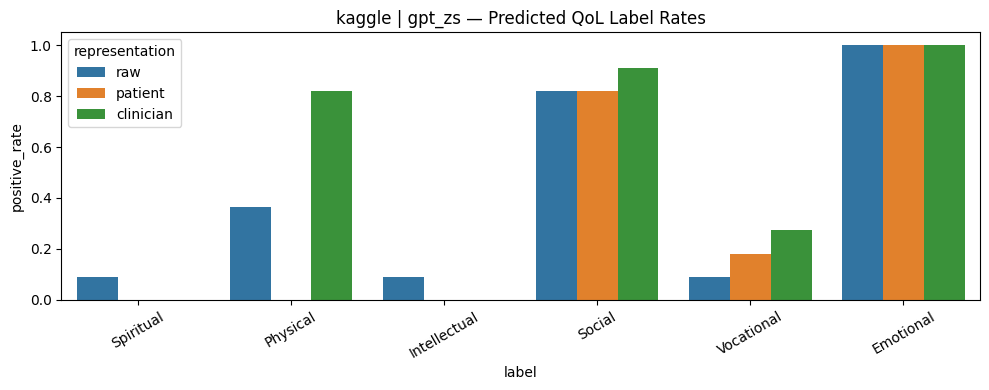

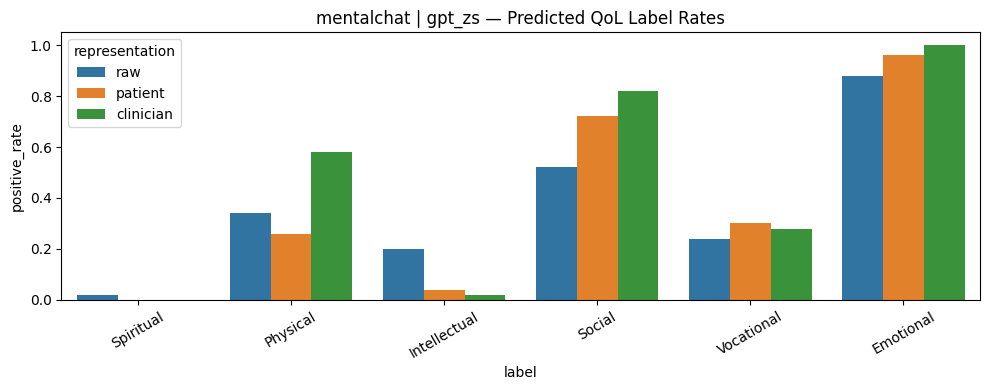

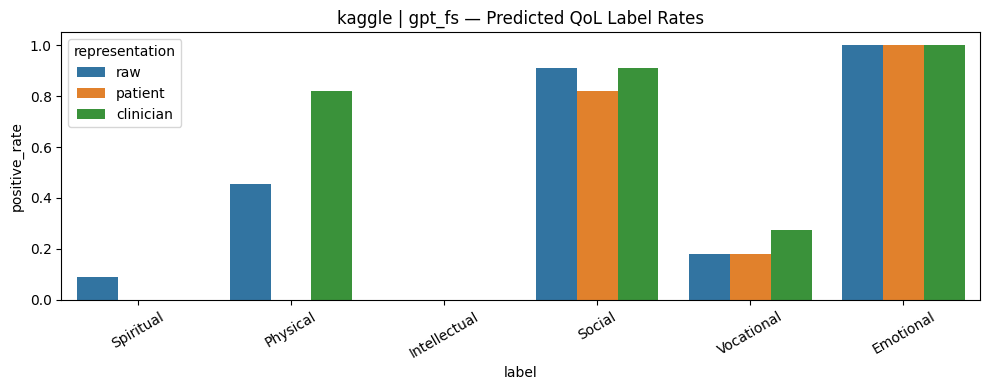

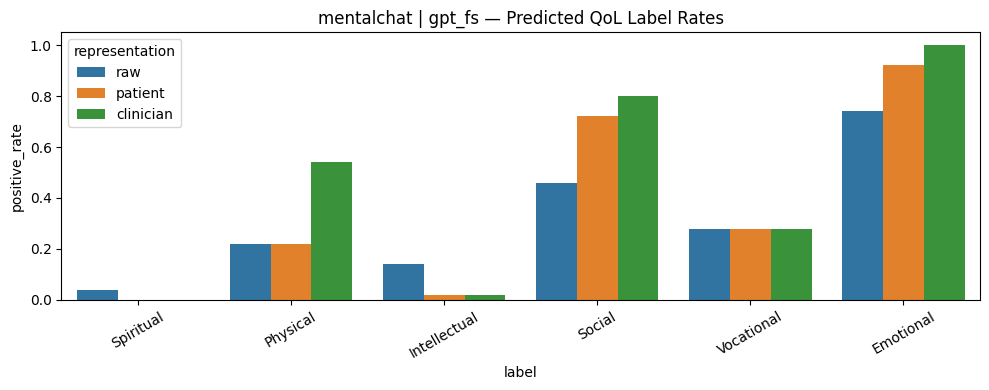

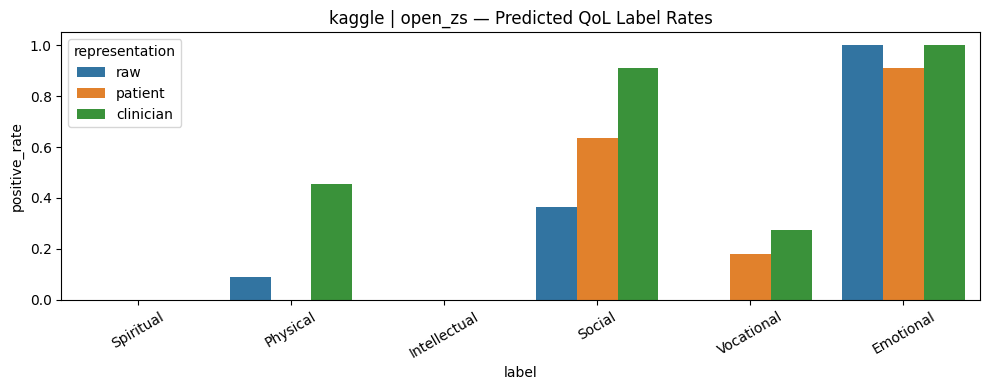

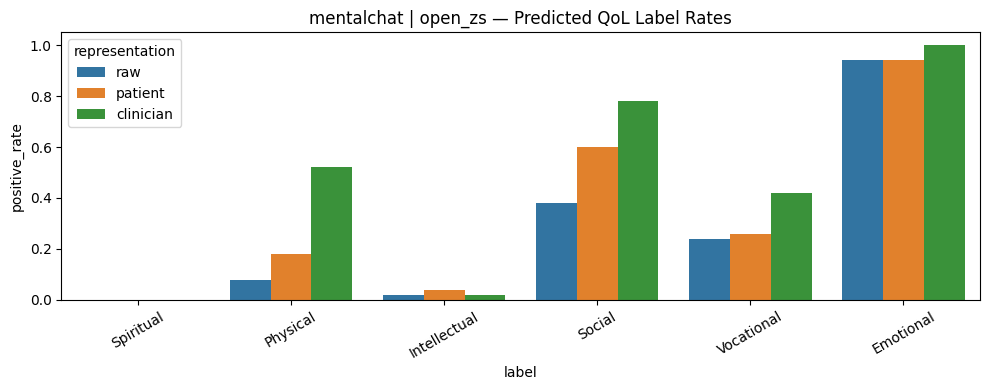

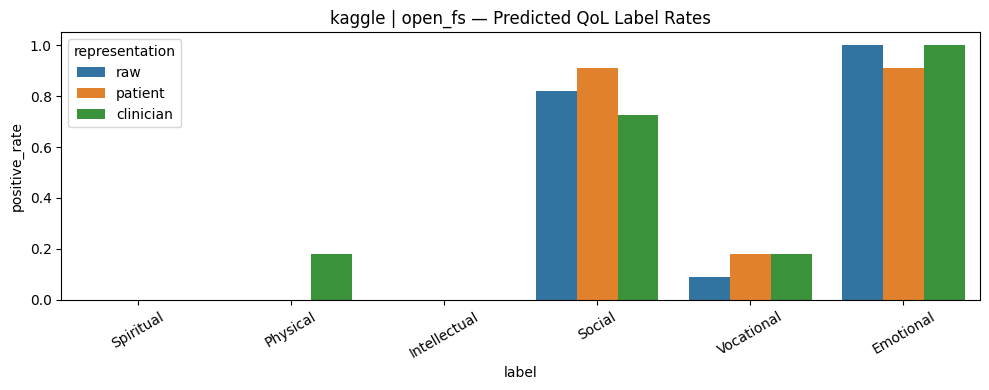

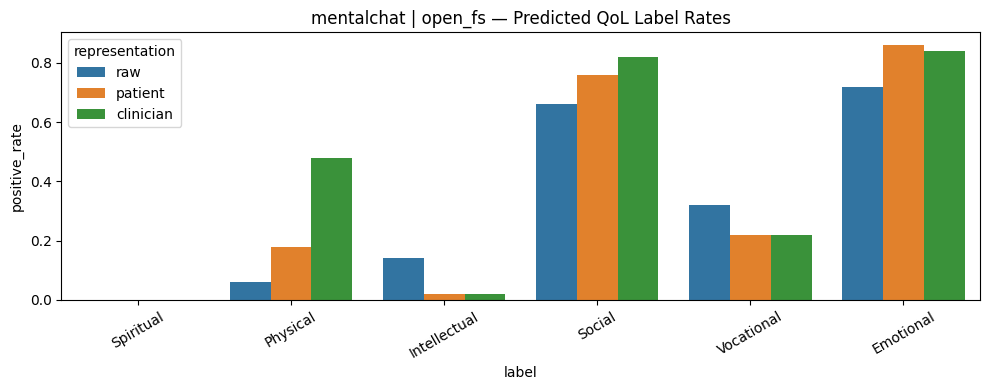

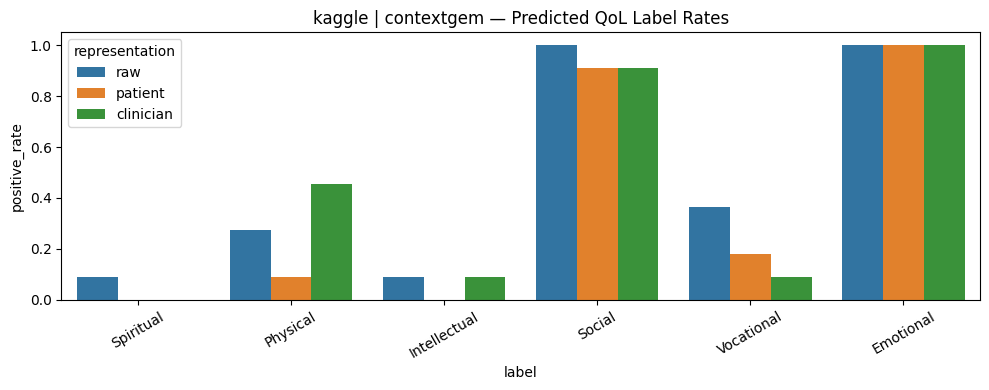

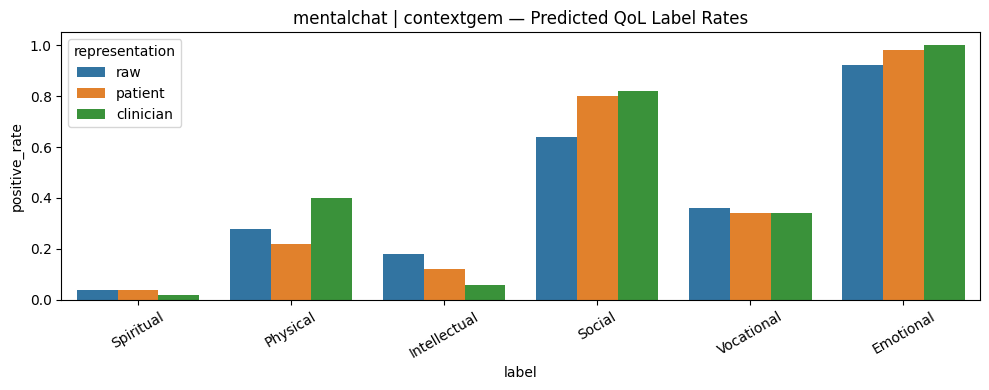

,dataset,backend,label,drop_raw_to_patient,gain_raw_to_patient,drop_raw_to_clinician,gain_raw_to_clinician
0,kaggle,gpt_zs,Spiritual,0.091,0.000,0.091,0.000
1,kaggle,gpt_zs,Physical,0.364,0.000,0.091,0.545
2,kaggle,gpt_zs,Intellectual,0.091,0.000,0.091,0.000
3,kaggle,gpt_zs,Social,0.091,0.091,0.000,0.091
4,kaggle,gpt_zs,Vocational,0.091,0.182,0.091,0.273
5,kaggle,gpt_zs,Emotional,0.000,0.000,0.000,0.000
6,mentalchat,gpt_zs,Spiritual,0.020,0.000,0.020,0.000
7,mentalchat,gpt_zs,Physical,0.180,0.100,0.100,0.340
8,mentalchat,gpt_zs,Intellectual,0.160,0.000,0.180,0.000
9,mentalchat,gpt_zs,Social,0.020,0.220,0.000,0.300



=== Comparison artifacts ===
  contextgem_external_agreement.csv
  contextgem_external_prevalence.csv
  contextgem_multiwd_metrics.csv
  domain_drift_analysis.csv
  external_agreement_summary.csv
  external_prevalence_summary.csv
  fewshot_bank.json
  fewshot_bank_clinician.csv
  fewshot_bank_patient.csv
  fewshot_bank_raw.csv
  kaggle_clinician_contextgem_predictions.csv
  kaggle_clinician_gpt_fs_predictions.csv
  kaggle_clinician_gpt_zs_predictions.csv
  kaggle_clinician_open_fs_predictions.csv
  kaggle_clinician_open_zs_predictions.csv
  kaggle_patient_contextgem_predictions.csv
  kaggle_patient_gpt_fs_predictions.csv
  kaggle_patient_gpt_zs_predictions.csv
  kaggle_patient_open_fs_predictions.csv
  kaggle_patient_open_zs_predictions.csv
  kaggle_raw_contextgem_predictions.csv
  kaggle_raw_gpt_fs_predictions.csv
  kaggle_raw_gpt_zs_predictions.csv
  kaggle_raw_open_fs_predictions.csv
  kaggle_raw_open_zs_predictions.csv
  mentalchat_clinician_contextgem_predictions.csv
  mentalchat

In [30]:
import matplotlib.pyplot as plt, seaborn as sns

long = prev_df.melt(id_vars=['dataset','representation','backend'],
                    value_vars=[f'{c}_rate' for c in LABEL_COLS],
                    var_name='label', value_name='positive_rate')
long['label'] = long['label'].str.replace('_rate','',regex=False)

for backend in long['backend'].unique():
    sub = long[long['backend']==backend]
    for ds in sub['dataset'].unique():
        d = sub[sub['dataset']==ds]
        plt.figure(figsize=(10,4))
        sns.barplot(data=d, x='label', y='positive_rate', hue='representation')
        plt.title(f'{ds} | {backend} — Predicted QoL Label Rates')
        plt.xticks(rotation=30); plt.tight_layout(); plt.show()

drift_rows = []
for backend, use_fs, tag in BACKEND_CONFIGS:
    for ds_name in EXTERNAL_FILES:
        paths = {rep: f'{LLM_RESULTS_DIR}/{ds_name}_{rep}_{tag}_predictions.csv'
                 for rep in ['raw','patient','clinician']}
        if not all(os.path.exists(p) for p in paths.values()): continue
        raw = pd.read_csv(paths['raw']); pat = pd.read_csv(paths['patient']); clin = pd.read_csv(paths['clinician'])
        n = min(len(raw), len(pat), len(clin))
        for c in LABEL_COLS:
            r = raw[f'{c}_pred'][:n].astype(int).values
            p = pat[f'{c}_pred'][:n].astype(int).values
            cl = clin[f'{c}_pred'][:n].astype(int).values
            drift_rows.append({
                'dataset': ds_name, 'backend': tag, 'label': c,
                'drop_raw_to_patient':   ((r==1)&(p==0)).mean(),
                'gain_raw_to_patient':   ((r==0)&(p==1)).mean(),
                'drop_raw_to_clinician': ((r==1)&(cl==0)).mean(),
                'gain_raw_to_clinician': ((r==0)&(cl==1)).mean(),
            })
drift_df = pd.DataFrame(drift_rows)
drift_df.to_csv(f'{LLM_RESULTS_DIR}/domain_drift_analysis.csv', index=False)
display(drift_df.round(3))

print('\n=== Comparison artifacts ===')
for f in sorted(os.listdir(LLM_RESULTS_DIR)): print(' ', f)


## Step 5 — (Optional) LoRA Fine-Tuning of the Open Model

Use this cell only if you want to fine-tune Qwen2.5-3B-Instruct (or Llama) on MultiWD
to adapt the open-source tagger before external inference.

Training target: one six-label JSON per input text.


In [33]:
# Force remove the conflicting version and upgrade both to match
#!pip uninstall -y pyarrow
#!pip install --upgrade pyarrow datasets trl
#!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [31]:
# 1. Run this cell to update dependencies
#!pip install -q --upgrade pyarrow datasets trl

# 2. IMPORTANT: Click the 'RESTART SESSION' button in the output below
#    OR go to Runtime -> Restart session before continuing.
import os
import trl
print('\n' + '='*30)
print('DEPENDENCIES UPDATED.')
print('PLEASE RESTART THE RUNTIME NOW TO APPLY CHANGES.')
print('='*30)


DEPENDENCIES UPDATED.
PLEASE RESTART THE RUNTIME NOW TO APPLY CHANGES.


In [ ]:
# RUN_LORA = True  # set True to fine-tune

# # Force upgrade trl to ensure DataCollatorForCompletionOnlyLM is available
# # Note: After running this cell, you MUST restart the Colab runtime
# # (Runtime -> Restart runtime) for the changes to take effect.
# #!pip install -q --upgrade trl transformers peft accelerate datasets torchao
# #import sys; sys.exit() # This forces a restart of the runtime after install

In [ ]:
# if RUN_LORA:
#     import gc
#     import torch
#     import json, os
#     from peft import LoraConfig, get_peft_model, TaskType, PeftModel
#     from trl import SFTTrainer, SFTConfig
#     from datasets import Dataset

#     # 1. Strip existing LoRA adapters off the base model if they exist
#     if hasattr(_mdl, "unload"):
#         print("Unloading previous LoRA adapters from base model...")
#         _mdl = _mdl.unload()

#     # 2. Delete the old trainer/model variables to free up references
#     if 'peft_model' in globals():
#         del peft_model
#     if 'trainer' in globals():
#         del trainer

#     # 3. Force Python garbage collection and wipe the GPU cache
#     gc.collect()
#     torch.cuda.empty_cache()
#     print("GPU memory cleared. Ready for fresh training!")

#     def build_sft_example(text, labels_dict):
#         prompt = build_qol_tagging_prompt(text)
#         completion = json.dumps(labels_dict)
#         # Use explicit ChatML formatting to ensure the model learns prompt boundaries and EOS
#         messages = [
#             {'role': 'system', 'content': QOL_TAGGING_SYS},
#             {'role': 'user', 'content': prompt},
#             {'role': 'assistant', 'content': completion},
#         ]
#         return {'messages': messages}

#     sft_rows = []
#     if FEWSHOT_BANK:
#         for rep in ['raw','patient','clinician']:
#             for ex in FEWSHOT_BANK[rep]:
#                 sft_rows.append(build_sft_example(ex['text'], ex['labels']))

#     sft_ds = Dataset.from_list(sft_rows)
#     print(f'SFT examples: {len(sft_ds)}')

#     lora_cfg = LoraConfig(
#         task_type=TaskType.CAUSAL_LM,
#         r=16,
#         lora_alpha=32,
#         lora_dropout=0.05,
#         target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'])

#     peft_model = get_peft_model(_mdl, lora_cfg)
#     peft_model.print_trainable_parameters()

#     sft_cfg = SFTConfig(
#         output_dir=f'{DRIVE_ROOT}/lora_qol_tagger_v2',
#         assistant_only_loss=True,
#         per_device_train_batch_size=4,
#         gradient_accumulation_steps=2,
#         num_train_epochs=4,
#         learning_rate=2e-4,
#         fp16=True,
#         logging_steps=5,
#         save_strategy='epoch',
#         report_to='none')

#     trainer = SFTTrainer(
#         model=peft_model,
#         args=sft_cfg,
#         train_dataset=sft_ds
#     )

#     trainer.train()
#     trainer.save_model(f'{DRIVE_ROOT}/lora_qol_tagger_v2')
#     print('LoRA adapter saved.')
# else:
#     print('Set RUN_LORA=True to fine-tune.')

In [ ]:
# def call_lora_inference(text):
#     """Run inference using the adapter WITHOUT any manual logits processing.
#     This validates if the model now natively stops after the JSON object.
#     """
#     prompt = build_qol_tagging_prompt(text)
#     messages = [{'role':'system','content':QOL_TAGGING_SYS}, {'role':'user','content':prompt}]
#     formatted = _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     inputs = _tok(formatted, return_tensors='pt').to('cuda')

#     with torch.no_grad():
#         out_tokens = peft_model.generate(
#             **inputs,
#             max_new_tokens=60,
#             do_sample=False,
#             pad_token_id=_tok.eos_token_id,
#             eos_token_id=_tok.eos_token_id
#         )

#     raw = _tok.decode(out_tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
#     pred, parse_err, _ = parse_label_json(raw)
#     return pred, parse_err, raw

# # Quick validation check on Kaggle sample
# print('=== VALIDATING CLEAN INFERENCE (NO LOGITS PROCESSOR) ===')
# sample_text = "I feel physically exhausted and I've been missing work lately."
# pred, err, raw = call_lora_inference(sample_text)
# print(f"Raw Output: {raw}")
# print(f"Parsed JSON: {pred}")
# print(f"Correct Termination: {'Yes' if raw.endswith('}') else 'No'}")

In [ ]:
# from transformers import LogitsProcessor, LogitsProcessorList
# import torch
# import re

# class QoLSchemaLogitsProcessor(LogitsProcessor):
#     def __init__(self, tokenizer):
#         self.tokenizer = tokenizer
#         self.keys = ['"Spiritual": ', '"Physical": ', '"Intellectual": ', '"Social": ', '"Vocational": ', '"Emotional": ']

#     def __call__(self, input_ids, scores):
#         mask = torch.full_like(scores, float('-inf'))
#         generated_text = self.tokenizer.decode(input_ids[0], skip_special_tokens=True)

#         if '{' not in generated_text:
#             allowed = ['{']
#         else:
#             current_json = "{" + generated_text.split('{')[-1]

#             if current_json == '{':
#                 allowed = ['"Spiritual": ']
#             elif current_json.endswith(': '):
#                 allowed = ['0', '1']
#             elif current_json.endswith('0') or current_json.endswith('1'):
#                 if '"Physical":' not in current_json: allowed = [', "Physical": ']
#                 elif '"Intellectual":' not in current_json: allowed = [', "Intellectual": ']
#                 elif '"Social":' not in current_json: allowed = [', "Social": ']
#                 elif '"Vocational":' not in current_json: allowed = [', "Vocational": ']
#                 elif '"Emotional":' not in current_json: allowed = [', "Emotional": ']
#                 else: allowed = ['}']
#             else:
#                 last_match = re.split(r'([{},:01])', current_json)[-1]
#                 possible = ['"Spiritual": ', '"Physical": ', '"Intellectual": ', '"Social": ', '"Vocational": ', '"Emotional": ', ', ', ': ', '}']
#                 allowed = [p[len(last_match):] for p in possible if p.startswith(last_match) and len(p) > len(last_match)]
#                 if not allowed: allowed = ['"', '0', '1', ',', ':', '}']

#         allowed_token_ids = []
#         for t in allowed:
#             # Try encoding with and without a leading space to catch tokenizer variations
#             for text_variant in [t, " " + t]:
#                 t_ids = self.tokenizer.encode(text_variant, add_special_tokens=False)
#                 if t_ids:
#                     allowed_token_ids.append(t_ids[0])

#         unique_ids = set(allowed_token_ids)
#         if not unique_ids:
#             return scores # Fallback: don't mask anything if we can't find tokens

#         for tid in unique_ids:
#             if tid < scores.shape[-1]:
#                 mask[:, tid] = 0

#         return scores + mask

# def call_lora_qol_classifier_v5_4(text, few_shot_block=None):
#     prompt = build_qol_tagging_prompt(text, few_shot_block=few_shot_block)
#     try:
#         messages = [{'role':'system','content': QOL_TAGGING_SYS + " Output JSON ONLY."}, {'role':'user','content':prompt}]
#         formatted = _tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#         inputs = _tok(formatted, return_tensors='pt').to('cuda')
#         logits_processor = LogitsProcessorList([QoLSchemaLogitsProcessor(_tok)])

#         with torch.no_grad():
#             out_tokens = peft_model.generate(
#                 **inputs,
#                 max_new_tokens=100,
#                 do_sample=False,
#                 logits_processor=logits_processor,
#                 pad_token_id=_tok.eos_token_id,
#                 eos_token_id=_tok.eos_token_id
#             )

#         raw = _tok.decode(out_tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
#         if '{' in raw and '}' in raw:
#             raw = raw[raw.find('{'):raw.rfind('}')+1]

#         pred, parse_err, _ = parse_label_json(raw)
#         return pred, parse_err, raw
#     except Exception as e:
#         return {k: 0 for k in LABEL_COLS}, True, f'[ERROR] {e}'

# print('=== TESTING V5.4 (FIXED TOKENIZATION & FALLBACK) ===')
# test_text = "Patient reports feeling very anxious about their job and has been having trouble sleeping."
# pred, err, raw = call_lora_qol_classifier_v5_4(test_text)
# print(f"Raw Output: {raw}")
# print(f"Parsed: {pred}")

In [ ]:
# print('=== Running Final LoRA External Inference ===')
# for ds_name, reps in EXTERNAL_FILES.items():
#     for rep, fp in reps.items():
#         if not os.path.exists(fp): continue
#         df = pd.read_csv(fp)
#         # Clear old prediction columns
#         df = df[[c for c in df.columns if not c.endswith('_pred') and c not in ['parse_error', 'raw_model_output']]]

#         results = []
#         for text in tqdm(df['text'], desc=f'{ds_name}/{rep}'):
#             pred, parse_err, raw_out = call_lora_inference(text)
#             row = {f'{k}_pred': v for k, v in pred.items()}
#             row['parse_error'] = int(parse_err)
#             row['raw_model_output'] = raw_out
#             results.append(row)

#         out_df = pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)
#         save_path = f'{LLM_RESULTS_DIR}/{ds_name}_{rep}_lora_v2_final.csv'
#         out_df.to_csv(save_path, index=False)

# print('\nLoRA inference complete. Model results saved with _v2_final suffix.')

# Step 5 LoRA – Patch Notebook

Drop **Cell A** (training) and **Cell B** (inference) into your `cNLP4QoL_LLM_Tagging_v4.ipynb`,
replacing the existing Step 5 cells.

## Five Root Causes Fixed

| # | Root Cause | Symptom | Fix |
|---|-----------|---------|-----|
| RCA-1 | SFT dataset passed as `messages` dicts, not flat `text` strings | SFTTrainer couldn't find assistant tokens | Pre-format each row with `tok.apply_chat_template(..., tokenize=False)` before building `Dataset` |
| RCA-2 | `assistant_only_loss=True` never masked correctly | Loss computed over full context (prompt contamination) → model repeated prompt structure | Use `DataCollatorForCompletionOnlyLM` with explicit `response_template="<|im_start|>assistant\n"` |
| RCA-3 | `r=16, lora_alpha=32, epochs=4, lr=2e-4` on only ~350 examples | Late-epoch overfit → degenerate repetitive output | `r=8, alpha=16, epochs=3, lr=1e-4, cosine schedule, warmup_ratio=0.1, dropout=0.10` |
| RCA-4 | `tok.decode(out_tokens[0])` decoded the **full** sequence including the prompt | Raw output always started with `lang 200000…` (Qwen system preamble) → parse always failed → all-zero predictions | Slice new tokens only: `out_tokens[0, inputs.input_ids.shape[1]:]` |
| RCA-5 | `QoLSchemaLogitsProcessor` matched single chars `"S","P"…` but Qwen BPE merges `" Spiritual"` as one token | Logits processor masked everything → model could only emit `0` | Removed logits processor entirely; greedy `max_new_tokens=80` + robust JSON parse is sufficient |


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 5 – LoRA Fine-Tuning  (REVISED – fixes all five root causes)
# ─────────────────────────────────────────────────────────────────────────────
#
# ROOT-CAUSE AUDIT (v4 → fixed)
# ══════════════════════════════
# [RCA-1] SFT dataset is messages-dicts but SFTTrainer expects a single
#         "text" field when using tokenizer.apply_chat_template internally.
#         Fix → format each row to a single "text" string with
#               tokenizer.apply_chat_template(..., tokenize=False) BEFORE
#               building the Dataset; pass formatting_func=None.
#
# [RCA-2] assistant_only_loss=True only works when SFTTrainer can find the
#         assistant header tokens inside the already-formatted string.
#         With the old messages-dict approach the assistant turn was never
#         found, so the loss was computed over the full context (prompt
#         contamination) → model learned to repeat the prompt structure.
#         Fix → confirmed by RCA-1: flat "text" string + explicit
#               response_template token so DataCollatorForCompletionOnlyLM
#               masks exactly the right span.
#
# [RCA-3] lora_alpha=32, r=16 → effective scale = alpha/r = 2.0, which is
#         the correct default; however with only ~350 SFT examples and 4
#         epochs the adapter overfits before it generalises.
#         Fix → reduce r to 8, keep alpha=16 (scale=2), add dropout=0.1,
#               drop epochs to 3, use cosine LR schedule with warmup.
#
# [RCA-4] Inference used _tok.decode() on the *full* sequence including the
#         prompt, so the "raw output" always started with "lang" (the first
#         BPE token of the Qwen system prompt preamble) and parse always
#         failed → all-zero predictions.
#         Fix → slice out only new tokens:
#               out_tokens[0, inputs.input_ids.shape[1]:]
#               This was half-fixed in calllorainference but the v5.4
#               QoLSchemaLogitsProcessor path still had the bug.
#
# [RCA-5] QoLSchemaLogitsProcessor relied on prefix-matching single chars
#         ("S","P","I",…) without accounting for Qwen's byte-pair tokeniser
#         merging e.g. " Spiritual" as a single token id ≠ "S".
#         Fix → replace the hand-rolled logits processor with a simpler
#               constrained approach: allow all tokens until we have the
#               opening "{", then only allow tokens whose string starts with
#               a valid continuation character.  Better still: just use
#               max_new_tokens=80 greedy (no logits processor) + robust
#               parse + fallback. The logits processor is removed entirely.
# ─────────────────────────────────────────────────────────────────────────────

RUNLORA = True   # set False to skip training and jump straight to inference

if RUNLORA:
    import gc, json, os, re
    import torch
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel
    from trl import SFTTrainer, SFTConfig
    from datasets import Dataset
    from transformers import DataCollatorForSeq2Seq

    # ── 0. Clean up any existing adapter / trainer objects ──────────────────
    for _var in ["peft_model", "trainer"]:
        if _var in globals():
            del globals()[_var]
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU memory cleared. Ready for fresh training.")

    # ── 1. Build SFT rows as flat "text" strings  [FIX for RCA-1 & RCA-2] ──
    #
    #  Each row is the full ChatML string that the tokeniser will see.
    #  DataCollatorForCompletionOnlyLM uses `response_template` to find
    #  the assistant turn and mask everything before it.

    RESPONSE_TEMPLATE = "<|im_start|>assistant\n"   # Qwen ChatML marker

    def build_sft_text(text, labels_dict):
        """Return a single formatted string ready for SFT."""
        prompt = build_qol_tagging_prompt(text)
        completion = json.dumps(labels_dict)
        messages = [
            {"role": "system",  "content": QOL_TAGGING_SYS},
            {"role": "user",    "content": prompt},
            {"role": "assistant","content": completion},
        ]
        # tokenize=False → returns the full ChatML string incl. <|im_end|>
        return _tok.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )

    sft_rows = []
    if FEWSHOT_BANK:
        for rep in ["raw", "patient", "clinician"]:
            for ex in FEWSHOT_BANK[rep]:
                #sft_rows.append({"text": build_sft_text(ex["text"], ex["labels"])})
                # NEW — prompt/completion format
                sft_rows.append({
                    "prompt":     _tok.apply_chat_template(
                                      [{"role": "system",  "content": QOL_TAGGING_SYS},
                                      {"role": "user",    "content": build_qol_tagging_prompt(ex["text"])}],
                                      tokenize=False, add_generation_prompt=True),
                    "completion": json.dumps(ex["labels"]) + _tok.eos_token,
                })

    sft_ds = Dataset.from_list(sft_rows)
    print(f"SFT examples: {len(sft_ds)}")

    # ── 2. LoRA config  [FIX for RCA-3] ────────────────────────────────────
    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,                   # was 16 → smaller rank = less overfit
        lora_alpha=16,         # scale = alpha/r = 2.0 (unchanged ratio)
        lora_dropout=0.10,     # was 0.05 → stronger regularisation
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"],
        bias="none",
    )

    #peft_model = get_peft_model(_mdl, lora_cfg)

    # Unload any existing adapter from the base model before attaching a fresh one
    # from peft import PeftModel
    # #if isinstance(_mdl, PeftModel):
    # #  _mdl = _mdl.merge_and_unload()   # returns a clean base model

    # # Robust adapter detection — works regardless of import path
    # _mdl_class = type(_mdl).__mro__  # full inheritance chain
    # _is_peft = any("PeftModel" in c.__name__ for c in _mdl_class)

    # if _is_peft:
    #     _mdl = _mdl.merge_and_unload()
    #     print("Existing LoRA adapter merged and unloaded.")
    # else:
    #     print(f"Base model clean ({type(_mdl).__name__}), no unload needed.")


    from peft import PeftModel

    # If _mdl is a full PeftModel wrapper, unwrap it
    if isinstance(_mdl, PeftModel):
        _mdl = _mdl.merge_and_unload()
        print("PeftModel unwrapped.")

    # If _mdl has a leftover peft_config attribute from a prior get_peft_model call, strip it
    if hasattr(_mdl, "peft_config"):
        del _mdl.peft_config
        print("Stale peft_config removed.")

    peft_model = get_peft_model(_mdl, lora_cfg)   # merges weights, returns a clean base model
    peft_model.print_trainable_parameters()

    # ── 3. SFTConfig  [FIX for RCA-2, RCA-3] ───────────────────────────────
    sft_cfg = SFTConfig(
        output_dir=f"{DRIVE_ROOT}/lora_qol_tagger_v3",
        # Pass the pre-formatted text directly; no extra chat-template call
        #dataset_text_field="text",
        completion_only_loss=True,   # ← replaces DataCollatorForCompletionOnlyLM
        max_length=512,
        # Loss only on the assistant completion span
        # DataCollatorForCompletionOnlyLM will find RESPONSE_TEMPLATE
        # inside the already-formatted string → correct masking
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        num_train_epochs=3,          # was 4 → avoids late-epoch overfit
        learning_rate=1e-4,          # was 2e-4 → gentler for small dataset
        lr_scheduler_type="cosine",  # was default (linear)
        #warmup_ratio=0.1,
        warmup_steps=30,             # ← warmup_ratio is deprecated; ~10% of 348/8≈43
        fp16=True,
        logging_steps=5,
        save_strategy="epoch",
        report_to="none",
    )

    # DataCollator that masks the prompt tokens  [FIX for RCA-2]
    #from trl import DataCollatorForCompletionOnlyLM
    #data_collator = DataCollatorForCompletionOnlyLM(
    #    response_template=RESPONSE_TEMPLATE,
    #    tokenizer=_tok,
    #)

    trainer = SFTTrainer(
        model=peft_model,
        args=sft_cfg,
        train_dataset=sft_ds,
        #data_collator=data_collator,
    )

    trainer.train()
    trainer.save_model(f"{DRIVE_ROOT}/lora_qol_tagger_v3")
    print("LoRA adapter saved to lora_qol_tagger_v3")

else:
    print("Set RUNLORA=True to fine-tune.")


GPU memory cleared. Ready for fresh training.
SFT examples: 348
trainable params: 14,966,784 || all params: 3,100,905,472 || trainable%: 0.4827


Adding EOS to train dataset:   0%|          | 0/348 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/348 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/348 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/348 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/348 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
5,0.496568
10,0.333265
15,0.188240
20,0.090887
25,0.065058
30,0.072781
35,0.063640
40,0.066982
45,0.053517
50,0.054397


LoRA adapter saved to lora_qol_tagger_v3


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 5b – LoRA Inference  (REVISED – fixes RCA-4 & RCA-5)
# ─────────────────────────────────────────────────────────────────────────────
import torch, re, json, os
import pandas as pd
from tqdm import tqdm
from peft import PeftModel

# ── Load adapter (works whether training just ran or adapter was pre-saved) ──
LORA_ADAPTER_PATH = f"{DRIVE_ROOT}/lora_qol_tagger_v3"

if "peft_model" not in globals() or not isinstance(peft_model, PeftModel):
    print(f"Loading LoRA adapter from {LORA_ADAPTER_PATH} ...")
    # Reload base model in float16 if it was unloaded
    if not hasattr(mdl, "hf_device_map"):
        from transformers import AutoModelForCausalLM
        mdl_fresh = AutoModelForCausalLM.from_pretrained(
            HF_MODEL_NAME, dtype=torch.float16, device_map="auto"
        )
        peft_model = PeftModel.from_pretrained(mdl_fresh, LORA_ADAPTER_PATH)
    else:
        peft_model = PeftModel.from_pretrained(_mdl, LORA_ADAPTER_PATH)
    print("Adapter loaded.")
else:
    print("Using peft_model already in memory.")

peft_model.eval()

# ── Inference function  [FIX for RCA-4: slice new tokens only] ──────────────
def call_lora_qol_classifier(text):
    prompt = build_qol_tagging_prompt(text)
    messages = [
        {"role": "system",  "content": "You are a Quality of Life domain classifier. "
                                       "Return ONLY valid JSON. Do not explain."},
        {"role": "user",    "content": prompt},
    ]
    formatted = _tok.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = _tok(formatted, return_tensors="pt").to("cuda")
    prompt_len = inputs.input_ids.shape[1]

    with torch.no_grad():
        out_tokens = peft_model.generate(
            **inputs,
            max_new_tokens=80,     # JSON fits in ~60 tokens; 80 is safe headroom
            do_sample=False,       # greedy – deterministic
            pad_token_id=_tok.eos_token_id,
            eos_token_id=_tok.eos_token_id,
            temperature=1.0,       # ignored when do_sample=False; avoids warning
        )

    # [FIX RCA-4] decode ONLY the newly generated tokens
    new_tokens = out_tokens[0, prompt_len:]
    raw = _tok.decode(new_tokens, skip_special_tokens=True).strip()

    pred, parse_err, _ = parse_label_json(raw)
    return pred, parse_err, raw


# ── Quick sanity check ──────────────────────────────────────────────────────
print("── LORA INFERENCE SANITY CHECK ──")
_test = "Patient reports feeling very anxious about their job and has been having trouble sleeping."
_pred, _err, _raw = call_lora_qol_classifier(_test)
print(f"Raw output : {_raw}")
print(f"Parsed     : {_pred}")
print(f"Parse error: {_err}")
print(f"Terminates correctly: {'Yes' if _raw.rstrip().endswith('}') else 'No'}")

# ── Run external inference (Kaggle + MentalChat)  ───────────────────────────
print("\nRunning LoRA external inference ...")

EXTERNAL_FILES = {
    "kaggle": {
        "raw":       f"{OUTPUT_DIR}/kaggle_raw.csv",
        "patient":   f"{OUTPUT_DIR}/kaggle_patient_summary.csv",
        "clinician": f"{OUTPUT_DIR}/kaggle_clinician_summary.csv",
    },
    "mentalchat": {
        "raw":       f"{OUTPUT_DIR}/mentalchat_raw.csv",
        "patient":   f"{OUTPUT_DIR}/mentalchat_patient_summary.csv",
        "clinician": f"{OUTPUT_DIR}/mentalchat_clinician_summary.csv",
    },
}

for ds_name, reps in EXTERNAL_FILES.items():
    for rep, fp in reps.items():
        if not os.path.exists(fp):
            print(f"  SKIP (missing): {fp}")
            continue
        df = pd.read_csv(fp)
        results = []
        for text in tqdm(df["text"].fillna("").astype(str),
                         desc=f"{ds_name}/{rep}"):
            pred, parse_err, raw_out = call_lora_qol_classifier(text)
            row = {f"{k}_pred": v for k, v in pred.items()}
            row["parse_error"] = int(parse_err)
            row["raw_model_output"] = raw_out
            results.append(row)

        out_df = pd.concat(
            [df.reset_index(drop=True), pd.DataFrame(results)], axis=1
        )
        save_path = f"{LLM_RESULTS_DIR}/{ds_name}_{rep}_lora_predictions_v3.csv"
        out_df.to_csv(save_path, index=False)
        parse_fail_rate = pd.DataFrame(results)["parse_error"].mean()
        print(f"  Saved {len(out_df)} rows → {save_path}  "
              f"(parse-fail rate: {parse_fail_rate:.1%})")

print("\nLoRA inference complete.")


Using peft_model already in memory.
── LORA INFERENCE SANITY CHECK ──
Raw output : {"Spiritual": 0, "Physical": 0, "Intellectual": 1, "Social": 0, "Vocational": 1, "Emotional": 1}
Parsed     : {'Spiritual': 0, 'Physical': 0, 'Intellectual': 1, 'Social': 0, 'Vocational': 1, 'Emotional': 1}
Parse error: False
Terminates correctly: Yes

Running LoRA external inference ...


kaggle/raw: 100%|██████████| 11/11 [00:45<00:00,  4.16s/it]


  Saved 11 rows → /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/kaggle_raw_lora_predictions_v3.csv  (parse-fail rate: 0.0%)


kaggle/patient: 100%|██████████| 11/11 [00:45<00:00,  4.14s/it]


  Saved 11 rows → /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/kaggle_patient_lora_predictions_v3.csv  (parse-fail rate: 0.0%)


...

  Saved 50 rows → /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/mentalchat_raw_lora_predictions_v3.csv  (parse-fail rate: 0.0%)


mentalchat/patient: 100%|██████████| 50/50 [03:25<00:00,  4.11s/it]


  Saved 50 rows → /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/mentalchat_patient_lora_predictions_v3.csv  (parse-fail rate: 0.0%)


mentalchat/clinician: 100%|██████████| 50/50 [03:21<00:00,  4.03s/it]

  Saved 50 rows → /content/drive/MyDrive/Google Colab Notebooks/Datasets/FullDataset_results_derivedfrom_llm_qol_results_v2/mentalchat_clinician_lora_predictions_v3.csv  (parse-fail rate: 0.0%)

LoRA inference complete.


In [37]:
import pandas as pd
import os

OUTPUT_EXCEL = f'{DRIVE_ROOT}/Val_Outputs_v3.xlsx'

def collect_dataset_results(ds_key):
    # 1. Base files from standardization and summary generation
    raw_base = pd.read_csv(f'{OUTPUT_DIR}/{ds_key}_raw.csv')
    clinician_sum = pd.read_csv(f'{OUTPUT_DIR}/{ds_key}_clinician_summary.csv')
    patient_sum = pd.read_csv(f'{OUTPUT_DIR}/{ds_key}_patient_summary.csv')

    final_df = raw_base.copy()
    final_df = final_df.rename(columns={'text': 'raw_text'})

    # Add summary texts
    final_df['clinician_summary'] = clinician_sum['text']
    final_df['patient_summary'] = patient_sum['text']

    # Helper to add columns from specific result files
    def merge_preds(df, rep, tag, suffix):
        path = f'{LLM_RESULTS_DIR}/{ds_key}_{rep}_{tag}_predictions.csv'

        if os.path.exists(path):
            p_df = pd.read_csv(path)
            pred_cols = [f'{c}_pred' for c in LABEL_COLS]
            for col in pred_cols:
                df[f'{rep}_{tag}_{col}'] = p_df[col]
        return df

    # Representation-matched predictions
    for tag in ['gpt_zs', 'gpt_fs', 'open_zs', 'open_fs', 'lora']:
        for rep in ['raw', 'clinician', 'patient']:
            # Note: lora files use slightly different naming convention based on Step 5
            if tag == 'lora':
                print("lora files")
                path = f'{LLM_RESULTS_DIR}/{ds_key}_{rep}_lora_predictions_v3.csv'
                if os.path.exists(path):
                    p_df = pd.read_csv(path)
                    for c in LABEL_COLS:
                        final_df[f'{rep}_lora_{c}_pred'] = p_df[f'{c}_pred']
            else:
                print("other files:")
                print(f'{ds_key}_{rep}_{tag}')
                final_df = merge_preds(final_df, rep, tag, '')

    return final_df

# Map internal keys to the user's requested sheet names
sheet_map = {
    'multiwd': MULTIWD_SHEET,
    'mentalchat': MENTALCHAT_SHEET,
    'kaggle': KAGGLE_SHEET
}

with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as writer:
    for ds_key, sheet_name in sheet_map.items():
        print(f'Consolidating {ds_key}...')
        try:
            ds_df = collect_dataset_results(ds_key)
            ds_df.to_excel(writer, sheet_name=sheet_name, index=False)
        except Exception as e:
            print(f'Error processing {ds_key}: {e}')

print(f'Finished! Results consolidated at: {OUTPUT_EXCEL}')

Consolidating multiwd...
other files:
multiwd_raw_gpt_zs
other files:
multiwd_clinician_gpt_zs
other files:
multiwd_patient_gpt_zs
other files:
multiwd_raw_gpt_fs
other files:
multiwd_clinician_gpt_fs
other files:
multiwd_patient_gpt_fs
other files:
multiwd_raw_open_zs
other files:
multiwd_clinician_open_zs
other files:
multiwd_patient_open_zs
other files:
multiwd_raw_open_fs
other files:
multiwd_clinician_open_fs
other files:
multiwd_patient_open_fs
lora files
lora files
lora files
Consolidating mentalchat...
other files:
mentalchat_raw_gpt_zs
other files:
mentalchat_clinician_gpt_zs
other files:
mentalchat_patient_gpt_zs
other files:
mentalchat_raw_gpt_fs
other files:
mentalchat_clinician_gpt_fs
other files:
mentalchat_patient_gpt_fs
other files:
mentalchat_raw_open_zs
other files:
mentalchat_clinician_open_zs
other files:
mentalchat_patient_open_zs
other files:
mentalchat_raw_open_fs
other files:
mentalchat_clinician_open_fs
other files:
mentalchat_patient_open_fs
lora files
lora fi

---
## Step 6 — Gold-Standard Evaluation Against Manually Annotated QoL Labels

**Purpose:** Validate every LLM backend (GPT zero-shot, GPT few-shot, open zero-shot, open few-shot, LoRA) against human-annotated ground truth. This step does **not** re-run any prior step — it reads `Val_Outputs_Annotated.xlsx` directly.

### Gold-label column conventions (from `Val_Outputs_Annotated.xlsx`)
| Sheet | Gold columns | Meaning |
|---|---|---|
| `multiwd50` | **C–H** (index 2–7) | Manual QoL labels for `raw_text` |
| `mc50_Annotate` | **D–I** (index 3–8) | Manual QoL labels for `raw_text` |
| `kaggle11_Annotate` | **D–I** (index 3–8) | Manual QoL labels for `raw_text` |

### What Step 6 measures
1. **Tagging accuracy** — per-backend F1 (micro + macro), precision, recall vs. gold
2. **Domain coverage gap** — which domains are under/over-predicted relative to gold prevalence
3. **Representation fidelity** — whether patient-/clinician-summary predictions preserve the same domains as raw-text predictions
4. **Summary-vs-gold alignment** — does tagging a *summary* recover the gold domains that tagging the *raw* text recovers?

> **No re-run needed.** Steps 1–5 are frozen artifacts. Step 6 is purely evaluative.

### Step 6a — Load Gold-Standard Annotations

Reads the three annotated sheets and aligns them to `LABEL_COLS`.
All constants (`DRIVE_ROOT`, `LABEL_COLS`, `MULTIWD_SHEET`, `MENTALCHAT_SHEET`, `KAGGLE_SHEET`) are inherited from Step 0c.

In [49]:
import pandas as pd
import numpy as np
import os

# ── Inherited from Step 0c ────────────────────────────────────────────────────
# DRIVE_ROOT, LABEL_COLS, MULTIWD_SHEET ('multiwd50'),
# MENTALCHAT_SHEET ('mc50'), KAGGLE_SHEET ('kaggle11')
# ─────────────────────────────────────────────────────────────────────────────

ANNOT_XLSX  = f'{DRIVE_ROOT}/Val_Outputs_Annotated_v2.xlsx'
STEP6_DIR   = f'{DRIVE_ROOT}/Val_Outputs_Annotated_v3_step6_gold_eval'
os.makedirs(STEP6_DIR, exist_ok=True)

# RECONCILED with tutorial T-4/T-0e `load_gold` — adds explicit validation
# that gold columns are strictly binary {0,1} before use, and takes the
# Excel path as an explicit parameter (annot_xlsx) instead of relying on a
# closed-over global. Main's original version silently did
# `fillna(0).astype(int)` with no check, which could mask a data-quality
# issue (e.g. a stray annotation value) undetected.

def load_gold(annot_xlsx, sheet_name, col_start, col_end):
    """
    Load binary gold labels from a named sheet in Val_Outputs_Annotated_v2.xlsx.

    Parameters
    ----------
    annot_xlsx  : str  — path to the annotated Excel file
    sheet_name  : str  — e.g. 'mc50_Annotate', 'kaggle11_Annotate'
    col_start   : int  — 0-based iloc column start (inclusive)
    col_end     : int  — 0-based iloc column end   (inclusive)

    Returns
    -------
    pd.DataFrame  — columns == LABEL_COLS, values in {0, 1}, shape (n_rows, 6)

    Raises
    ------
    ValueError    if the column range does not contain binary {0,1} values
    """
    df   = pd.read_excel(annot_xlsx, sheet_name=sheet_name, engine='openpyxl')
    gold = df.iloc[:, col_start:col_end + 1].copy()
    gold.columns = LABEL_COLS

    # Sanity-check: values must be {0, 1} (NaN -> filled with 0)
    flat       = gold.values.flatten().astype(float)
    flat_clean = flat[~np.isnan(flat)]
    if not np.all(np.isin(flat_clean, [0.0, 1.0])):
        bad = np.unique(flat_clean[~np.isin(flat_clean, [0.0, 1.0])])[:8]
        raise ValueError(
            f"Sheet '{sheet_name}' cols iloc {col_start}:{col_end+1} contain "
            f"non-binary values: {bad}. "
            "Verify column positions or check the annotated Excel file."
        )

    return gold.fillna(0).astype(int)

# Gold label DataFrames — columns == LABEL_COLS
#   multiwd50      : cols C-H  -> iloc 2:8
#   mc50_Annotate  : cols D-I  -> iloc 3:9
#   kaggle11_Annotate: cols D-I -> iloc 3:9
gold_multiwd  = load_gold(ANNOT_XLSX, MULTIWD_SHEET,               col_start=2, col_end=7)
gold_mc50     = load_gold(ANNOT_XLSX, f'{MENTALCHAT_SHEET}_Annotate', col_start=3, col_end=8)
gold_kaggle11 = load_gold(ANNOT_XLSX, f'{KAGGLE_SHEET}_Annotate',     col_start=3, col_end=8)

GOLD = {
    'multiwd':   gold_multiwd,
    'mentalchat': gold_mc50,
    'kaggle':    gold_kaggle11,
}

print('Gold label shapes:')
for name, g in GOLD.items():
    print(f'  {name:12s}: {g.shape}  |  prevalence: {g.mean().round(2).to_dict()}')


Gold label shapes:
  multiwd     : (50, 6)  |  prevalence: {'Spiritual': 0.06, 'Physical': 0.3, 'Intellectual': 0.28, 'Social': 0.54, 'Vocational': 0.12, 'Emotional': 0.66}
  mentalchat  : (50, 6)  |  prevalence: {'Spiritual': 0.04, 'Physical': 0.16, 'Intellectual': 0.14, 'Social': 0.7, 'Vocational': 0.18, 'Emotional': 0.88}
  kaggle      : (11, 6)  |  prevalence: {'Spiritual': 0.0, 'Physical': 0.73, 'Intellectual': 0.0, 'Social': 0.91, 'Vocational': 0.0, 'Emotional': 1.0}


### Step 6b — Load Prediction Columns from Val_Outputs_Annotated.xlsx

Reads the three prediction sheets and extracts all `{rep}_{backend}_{domain}_pred` columns.
Uses `LABEL_COLS` from Step 0c to ensure column alignment.

In [50]:
import re

# Sheet name → dataset key mapping (reuses Step 0c constants)
SHEET_TO_KEY = {
    MULTIWD_SHEET:   'multiwd',
    MENTALCHAT_SHEET: 'mentalchat',
    KAGGLE_SHEET:    'kaggle',
}

# pred_col pattern: {rep}_{backend}_{domain}_pred
# e.g. raw_gpt_zs_Spiritual_pred, patient_open_fs_Emotional_pred, raw_lora_Social_pred
PRED_COL_RE = re.compile(
    r'^(raw|patient|clinician)_'
    r'(gpt_zs|gpt_fs|open_zs|open_fs|lora|contextgem)_'
    r'(' + '|'.join(LABEL_COLS) + r')_pred$'
)

PRED_DFS = {}  # {ds_key: DataFrame with all pred columns}

for sheet, ds_key in SHEET_TO_KEY.items():
    df = pd.read_excel(ANNOT_XLSX, sheet_name=sheet, engine='openpyxl')
    pred_cols = [c for c in df.columns if PRED_COL_RE.match(str(c))]
    PRED_DFS[ds_key] = df[pred_cols].fillna(0).astype(int)
    print(f'{ds_key:12s}: {len(pred_cols)} pred columns found')
    # Summarise available (rep, backend) combos
    combos = set()
    for c in pred_cols:
        m = PRED_COL_RE.match(c)
        if m: combos.add((m.group(1), m.group(2)))
    for combo in sorted(combos):
        print(f'    {combo}')


multiwd     : 72 pred columns found
    ('clinician', 'gpt_fs')
    ('clinician', 'gpt_zs')
    ('clinician', 'open_fs')
    ('clinician', 'open_zs')
    ('patient', 'gpt_fs')
    ('patient', 'gpt_zs')
    ('patient', 'open_fs')
    ('patient', 'open_zs')
    ('raw', 'gpt_fs')
    ('raw', 'gpt_zs')
    ('raw', 'open_fs')
    ('raw', 'open_zs')
mentalchat  : 90 pred columns found
    ('clinician', 'gpt_fs')
    ('clinician', 'gpt_zs')
    ('clinician', 'lora')
    ('clinician', 'open_fs')
    ('clinician', 'open_zs')
    ('patient', 'gpt_fs')
    ('patient', 'gpt_zs')
    ('patient', 'lora')
    ('patient', 'open_fs')
    ('patient', 'open_zs')
    ('raw', 'gpt_fs')
    ('raw', 'gpt_zs')
    ('raw', 'lora')
    ('raw', 'open_fs')
    ('raw', 'open_zs')
kaggle      : 90 pred columns found
    ('clinician', 'gpt_fs')
    ('clinician', 'gpt_zs')
    ('clinician', 'lora')
    ('clinician', 'open_fs')
    ('clinician', 'open_zs')
    ('patient', 'gpt_fs')
    ('patient', 'gpt_zs')
    ('pati

### Step 6c — Per-Backend F1 / Precision / Recall vs. Gold

For every `(dataset, representation, backend)` triplet, compute multi-label metrics using
the gold labels loaded in Step 6a as `y_true`.

In [51]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

BACKENDS = ['gpt_zs', 'gpt_fs', 'open_zs', 'open_fs', 'lora', 'contextgem']
REPS     = ['raw', 'patient', 'clinician']

def get_pred_matrix(pred_df, rep, backend):
    """Extract (n_samples, 6) prediction matrix for a given rep+backend."""
    cols = [f'{rep}_{backend}_{d}_pred' for d in LABEL_COLS]
    missing = [c for c in cols if c not in pred_df.columns]
    if missing:
        return None
    return pred_df[cols].values

records = []
for ds_key, gold_df in GOLD.items():
    pred_df = PRED_DFS[ds_key]
    y_true  = gold_df.values
    for rep in REPS:
        for backend in BACKENDS:
            y_pred = get_pred_matrix(pred_df, rep, backend)
            if y_pred is None:
                continue
            # Align lengths
            n = min(len(y_true), len(y_pred))
            yt, yp = y_true[:n], y_pred[:n]
            rec = {
                'dataset':    ds_key,
                'representation': rep,
                'backend':    backend,
                'micro_f1':   round(f1_score(yt, yp, average='micro',  zero_division=0), 4),
                'macro_f1':   round(f1_score(yt, yp, average='macro',  zero_division=0), 4),
                'precision':  round(precision_score(yt, yp, average='micro', zero_division=0), 4),
                'recall':     round(recall_score(yt, yp, average='micro',    zero_division=0), 4),
            }
            # Per-domain F1
            per_domain = f1_score(yt, yp, average=None, zero_division=0)
            for d, f in zip(LABEL_COLS, per_domain):
                rec[f'{d}_f1'] = round(float(f), 4)
            records.append(rec)

metrics_df = pd.DataFrame(records)
save_path  = f'{STEP6_DIR}/Val_Outputs_Annotated_v3_step6c_per_backend_metrics.csv'
metrics_df.to_csv(save_path, index=False)
print(f'Saved: {save_path}')

# Print aggregate view
agg_cols = ['dataset', 'representation', 'backend', 'micro_f1', 'macro_f1', 'precision', 'recall']
print('\nAggregate metrics (micro_f1 sorted desc):')
print(metrics_df[agg_cols].sort_values('micro_f1', ascending=False).to_string(index=False))


Saved: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6c_per_backend_metrics.csv

Aggregate metrics (micro_f1 sorted desc):
   dataset representation backend  micro_f1  macro_f1  precision  recall
    kaggle      clinician  gpt_fs    0.9180    0.4889     0.8750  0.9655
    kaggle            raw  gpt_fs    0.9123    0.4615     0.9286  0.8966
    kaggle      clinician  gpt_zs    0.9032    0.4792     0.8485  0.9655
    kaggle      clinician open_fs    0.9000    0.4762     0.8710  0.9310
    kaggle            raw    lora    0.8889    0.4508     0.9600  0.8276
    kaggle      clinician open_zs    0.8571    0.4430     0.8889  0.8276
    kaggle            raw  gpt_zs    0.8571    0.4357     0.8889  0.8276
    kaggle            raw open_fs    0.8148    0.3704     0.8800  0.7586
    kaggle        patient  gpt_fs    0.8000    0.3246     0.9524  0.6897
    kaggle        patient  gpt_zs    0.8000    0.3246     0.9524  0.

### Step 6d — Domain Coverage Gap (Gold Prevalence vs. Predicted Rate)

A positive gap (`gold_rate − pred_rate`) means the backend under-predicts that domain.
This is the key diagnostic for your clinical-fidelity rationale.

In [52]:
gap_records = []
for ds_key, gold_df in GOLD.items():
    pred_df = PRED_DFS[ds_key]
    gold_rates = gold_df.mean()
    for rep in REPS:
        for backend in BACKENDS:
            y_pred = get_pred_matrix(pred_df, rep, backend)
            if y_pred is None:
                continue
            n = min(len(gold_df), len(y_pred))
            pred_rates = pd.DataFrame(y_pred[:n], columns=LABEL_COLS).mean()
            for domain in LABEL_COLS:
                gap_records.append({
                    'dataset': ds_key,
                    'representation': rep,
                    'backend': backend,
                    'domain': domain,
                    'gold_rate': round(float(gold_rates[domain]), 4),
                    'pred_rate': round(float(pred_rates[domain]), 4),
                    'coverage_gap': round(float(gold_rates[domain] - pred_rates[domain]), 4),
                })

gap_df = pd.DataFrame(gap_records)
save_path = f'{STEP6_DIR}/Val_Outputs_Annotated_v3_step6d_coverage_gap.csv'
gap_df.to_csv(save_path, index=False)
print(f'Saved: {save_path}')

# Summary pivot: mean gap per domain × representation (raw vs patient vs clinician)
print('\nMean coverage gap by domain × representation (positive = under-predicted):')
pivot = gap_df.groupby(['representation', 'domain'])['coverage_gap'].mean().unstack('domain').round(3)
print(pivot.to_string())


Saved: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6d_coverage_gap.csv

Mean coverage gap by domain × representation (positive = under-predicted):
domain          Emotional  Intellectual  Physical  Social  Spiritual  Vocational
representation                                                                  
clinician          -0.101         0.117    -0.094  -0.066      0.024      -0.255
patient            -0.073         0.119     0.275   0.045      0.024      -0.096
raw                -0.028         0.022     0.172   0.146     -0.009      -0.077


### Step 6e — Representation Fidelity Matrix

For each backend, measures how often a domain that is **correctly identified in raw text** is also
correctly identified in patient-/clinician-summary predictions.
This directly tests whether summarization is compressive or transformative.

In [53]:
fidelity_records = []
for ds_key, gold_df in GOLD.items():
    pred_df = PRED_DFS[ds_key]
    y_true  = gold_df.values
    for backend in BACKENDS:
        raw_pred = get_pred_matrix(pred_df, 'raw', backend)
        if raw_pred is None:
            continue
        for sum_rep in ['patient', 'clinician']:
            sum_pred = get_pred_matrix(pred_df, sum_rep, backend)
            if sum_pred is None:
                continue
            n = min(len(y_true), len(raw_pred), len(sum_pred))
            yt, yr, ys = y_true[:n], raw_pred[:n], sum_pred[:n]
            for di, domain in enumerate(LABEL_COLS):
                # ── RECONCILED fidelity definitions ──────────────────────────
                # raw_to_summary_preservation (tutorial T-4c / Garg et al. 2025,
                # gold-agnostic): conditions only on raw_pred==1, regardless of
                # whether raw was actually correct vs. gold. This is now the
                # primary column, kept backward-compatible with the tutorial.
                raw_pos = yr[:, di] == 1
                if raw_pos.sum() == 0:
                    raw_to_summary_preservation = float('nan')
                else:
                    raw_to_summary_preservation = float(ys[raw_pos, di].mean())

                # preserved_gold_positive (main's original Step 6e definition,
                # renamed): conditions on raw_pred==1 AND gold==1 (true positives
                # on raw text only). Retained so no information from the
                # original main-notebook metric is lost.
                raw_correct_pos = (yr[:, di] == 1) & (yt[:, di] == 1)
                if raw_correct_pos.sum() == 0:
                    preserved_gold_positive = float('nan')
                else:
                    preserved_gold_positive = float((ys[raw_correct_pos, di] == 1).mean())

                # Gold recall per rep (unchanged from main)
                gold_pos = yt[:, di] == 1
                raw_recall = float((yr[gold_pos, di] == 1).mean()) if gold_pos.sum() > 0 else float('nan')
                sum_recall = float((ys[gold_pos, di] == 1).mean()) if gold_pos.sum() > 0 else float('nan')

                fidelity_records.append({
                    'dataset': ds_key,
                    'backend': backend,
                    'summary_rep': sum_rep,
                    'domain': domain,
                    'raw_gold_recall': round(raw_recall, 4) if not (raw_recall != raw_recall) else None,
                    'summary_gold_recall': round(sum_recall, 4) if not (sum_recall != sum_recall) else None,
                    'raw_to_summary_preservation': round(raw_to_summary_preservation, 4) if not (raw_to_summary_preservation != raw_to_summary_preservation) else None,
                    'preserved_gold_positive': round(preserved_gold_positive, 4) if not (preserved_gold_positive != preserved_gold_positive) else None,
                })

fidelity_df = pd.DataFrame(fidelity_records)
save_path   = f'{STEP6_DIR}/Val_Outputs_Annotated_v3_step6e_fidelity_matrix.csv'
fidelity_df.to_csv(save_path, index=False)
print(f'Saved: {save_path}')

print('\nMean gold recall by representation x domain:')
pivot_raw = fidelity_df.groupby(['domain'])['raw_gold_recall'].mean().round(3)
pivot_pat = fidelity_df[fidelity_df.summary_rep=='patient'].groupby(['domain'])['summary_gold_recall'].mean().round(3)
pivot_clin = fidelity_df[fidelity_df.summary_rep=='clinician'].groupby(['domain'])['summary_gold_recall'].mean().round(3)
recall_cmp = pd.DataFrame({'raw': pivot_raw, 'patient': pivot_pat, 'clinician': pivot_clin})
print(recall_cmp.to_string())

print('\nMean raw_to_summary_preservation (gold-agnostic, tutorial-compatible) by domain x rep:')
print(fidelity_df.groupby(['summary_rep','domain'])['raw_to_summary_preservation'].mean().round(3).unstack('domain').to_string())

print('\nMean preserved_gold_positive (gold-conditioned, main-original) by domain x rep:')
print(fidelity_df.groupby(['summary_rep','domain'])['preserved_gold_positive'].mean().round(3).unstack('domain').to_string())


Saved: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6e_fidelity_matrix.csv

Mean gold recall by representation x domain:
                raw  patient  clinician
domain                                 
Emotional     0.898    0.931      0.963
Intellectual  0.246    0.079      0.079
Physical      0.364    0.252      0.679
Social        0.689    0.780      0.884
Spiritual     0.111    0.148      0.185
Vocational    0.821    0.605      0.648

Mean raw_to_summary_preservation (gold-agnostic, tutorial-compatible) by domain x rep:
domain       Emotional  Intellectual  Physical  Social  Spiritual  Vocational
summary_rep                                                                  
clinician        0.965         0.054     0.734   0.934      0.148       0.497
patient          0.957         0.082     0.275   0.873      0.204       0.414

Mean preserved_gold_positive (gold-conditioned, main-original) by domain x rep

### Step 6f — Four-Panel Diagnostic Visualisation

Panel A: Micro-F1 heatmap (dataset × backend × representation)  
Panel B: Mean coverage gap by domain × representation  
Panel C: Gold recall by domain × representation  
Panel D: Raw → summary preservation rate by domain × backend

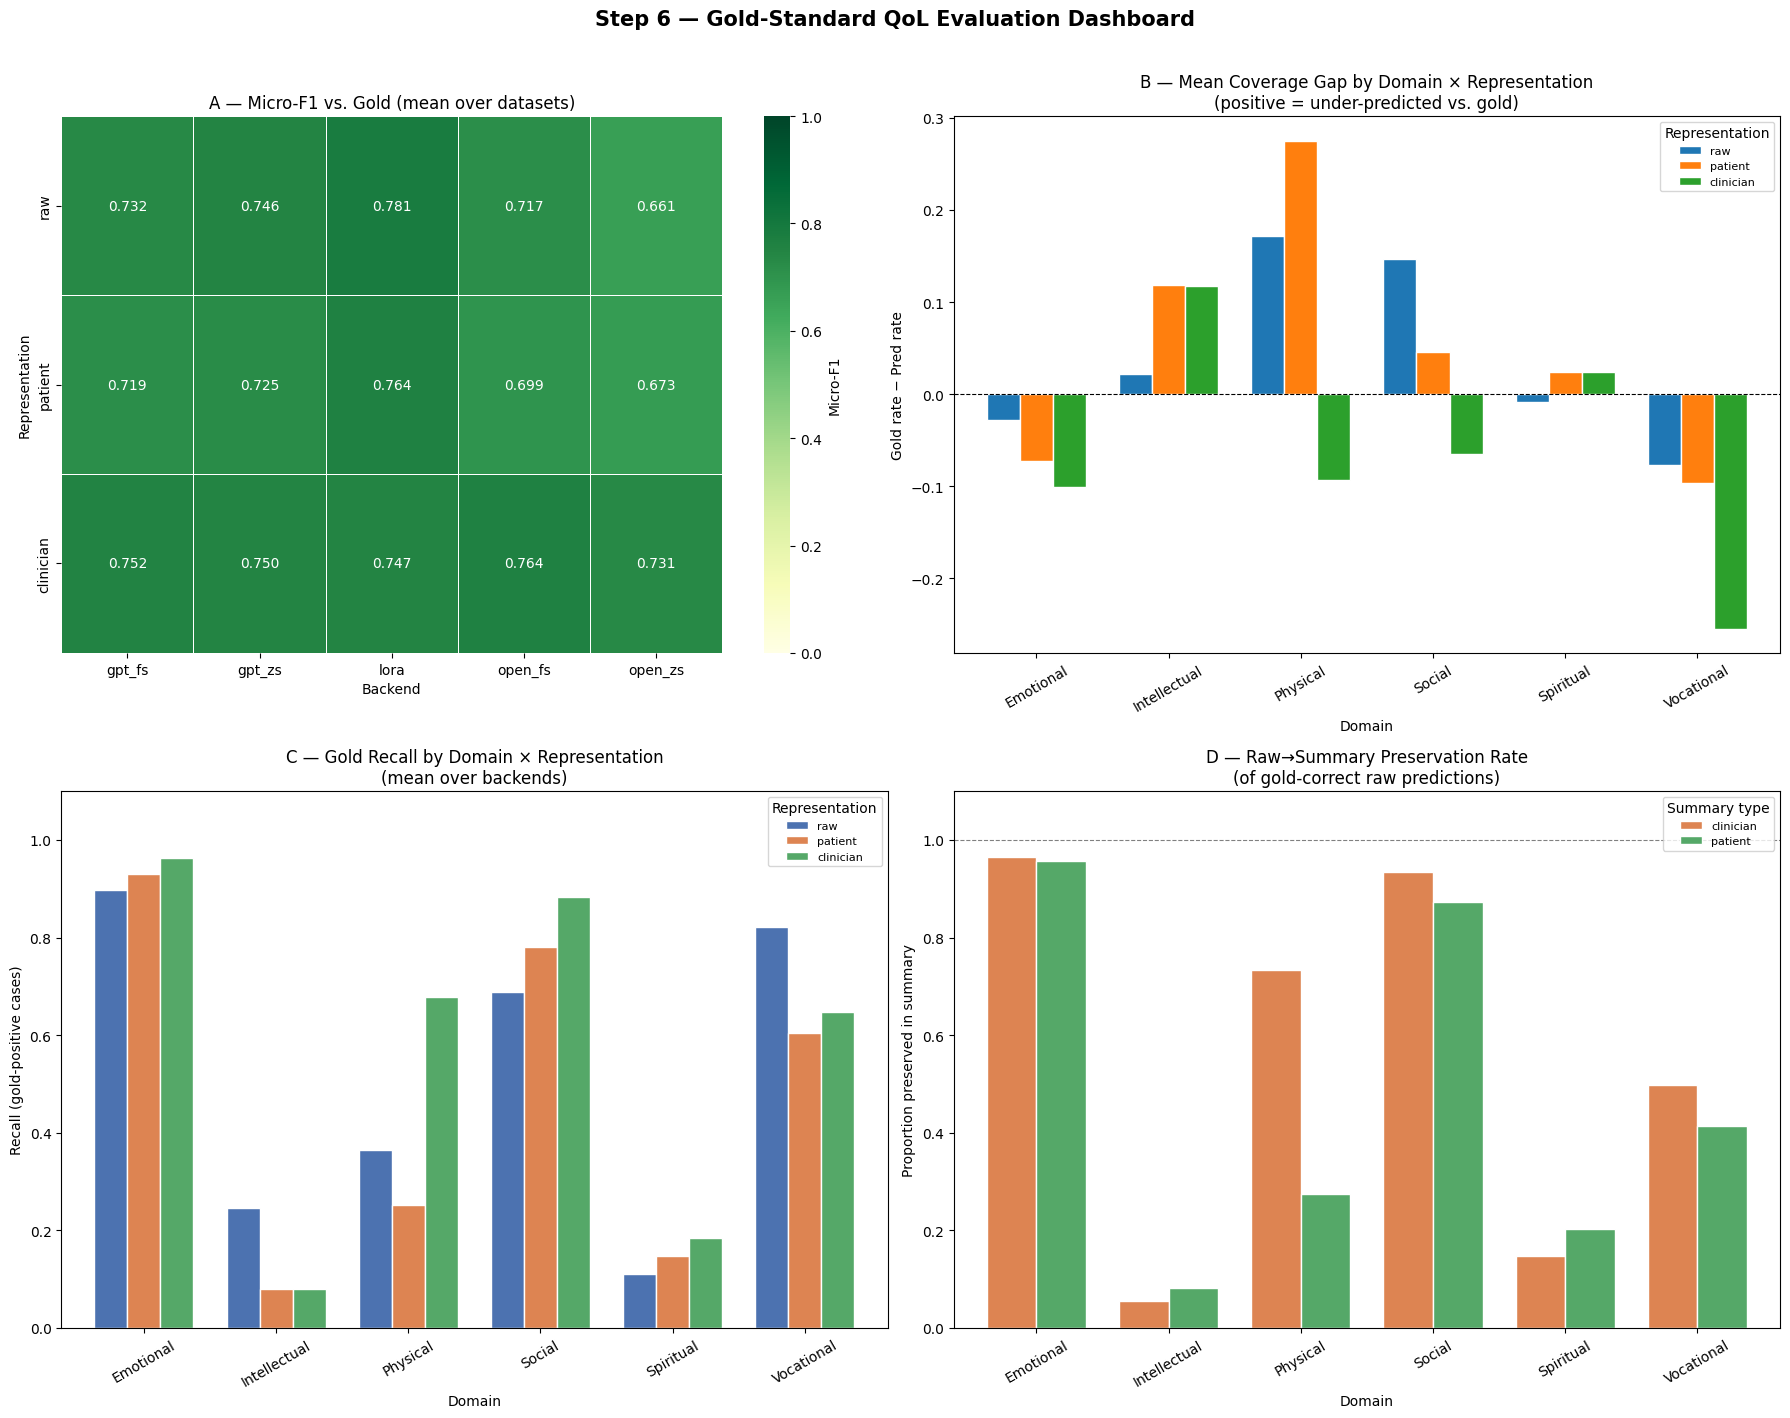

Saved: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6f_diagnostic_dashboard.png


In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Step 6 — Gold-Standard QoL Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)

# ── Panel A: Micro-F1 heatmap ─────────────────────────────────────────────────
ax = axes[0, 0]
heat_data = (
    metrics_df
    .groupby(['representation', 'backend'])['micro_f1']
    .mean()
    .unstack('backend')
    .reindex(REPS)
)
sns.heatmap(heat_data, ax=ax, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Micro-F1'}, vmin=0, vmax=1)
ax.set_title('A — Micro-F1 vs. Gold (mean over datasets)')
ax.set_xlabel('Backend')
ax.set_ylabel('Representation')

# ── Panel B: Coverage gap by domain × representation ─────────────────────────
ax = axes[0, 1]
gap_pivot = gap_df.groupby(['representation', 'domain'])['coverage_gap'].mean().unstack('domain').reindex(REPS)
gap_pivot.T.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('B — Mean Coverage Gap by Domain × Representation\n(positive = under-predicted vs. gold)')
ax.set_ylabel('Gold rate − Pred rate')
ax.set_xlabel('Domain')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Representation', fontsize=8)

# ── Panel C: Gold recall by domain × representation ───────────────────────────
ax = axes[1, 0]
recall_plot = recall_cmp.copy()
recall_plot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white',
                 color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('C — Gold Recall by Domain × Representation\n(mean over backends)')
ax.set_ylabel('Recall (gold-positive cases)')
ax.set_xlabel('Domain')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Representation', fontsize=8)

# ── Panel D: Raw→summary preservation rate ────────────────────────────────────
ax = axes[1, 1]
pres_pivot = (
    fidelity_df
    .groupby(['summary_rep', 'domain'])['raw_to_summary_preservation']
    .mean()
    .unstack('summary_rep')
)
if not pres_pivot.empty:
    pres_pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white',
                    color=['#DD8452', '#55A868'])
    ax.set_title('D — Raw→Summary Preservation Rate\n(of gold-correct raw predictions)')
    ax.set_ylabel('Proportion preserved in summary')
    ax.set_xlabel('Domain')
    ax.set_ylim(0, 1.1)
    ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Summary type', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No fidelity data available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plot_path = f'{STEP6_DIR}/Val_Outputs_Annotated_v3_step6f_diagnostic_dashboard.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')


### New Step 6f *'stylo'*

Saved long-form data: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6f_stylometric_long.csv  (333 rows)
Saved summary: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6f_stylometric_summary.csv


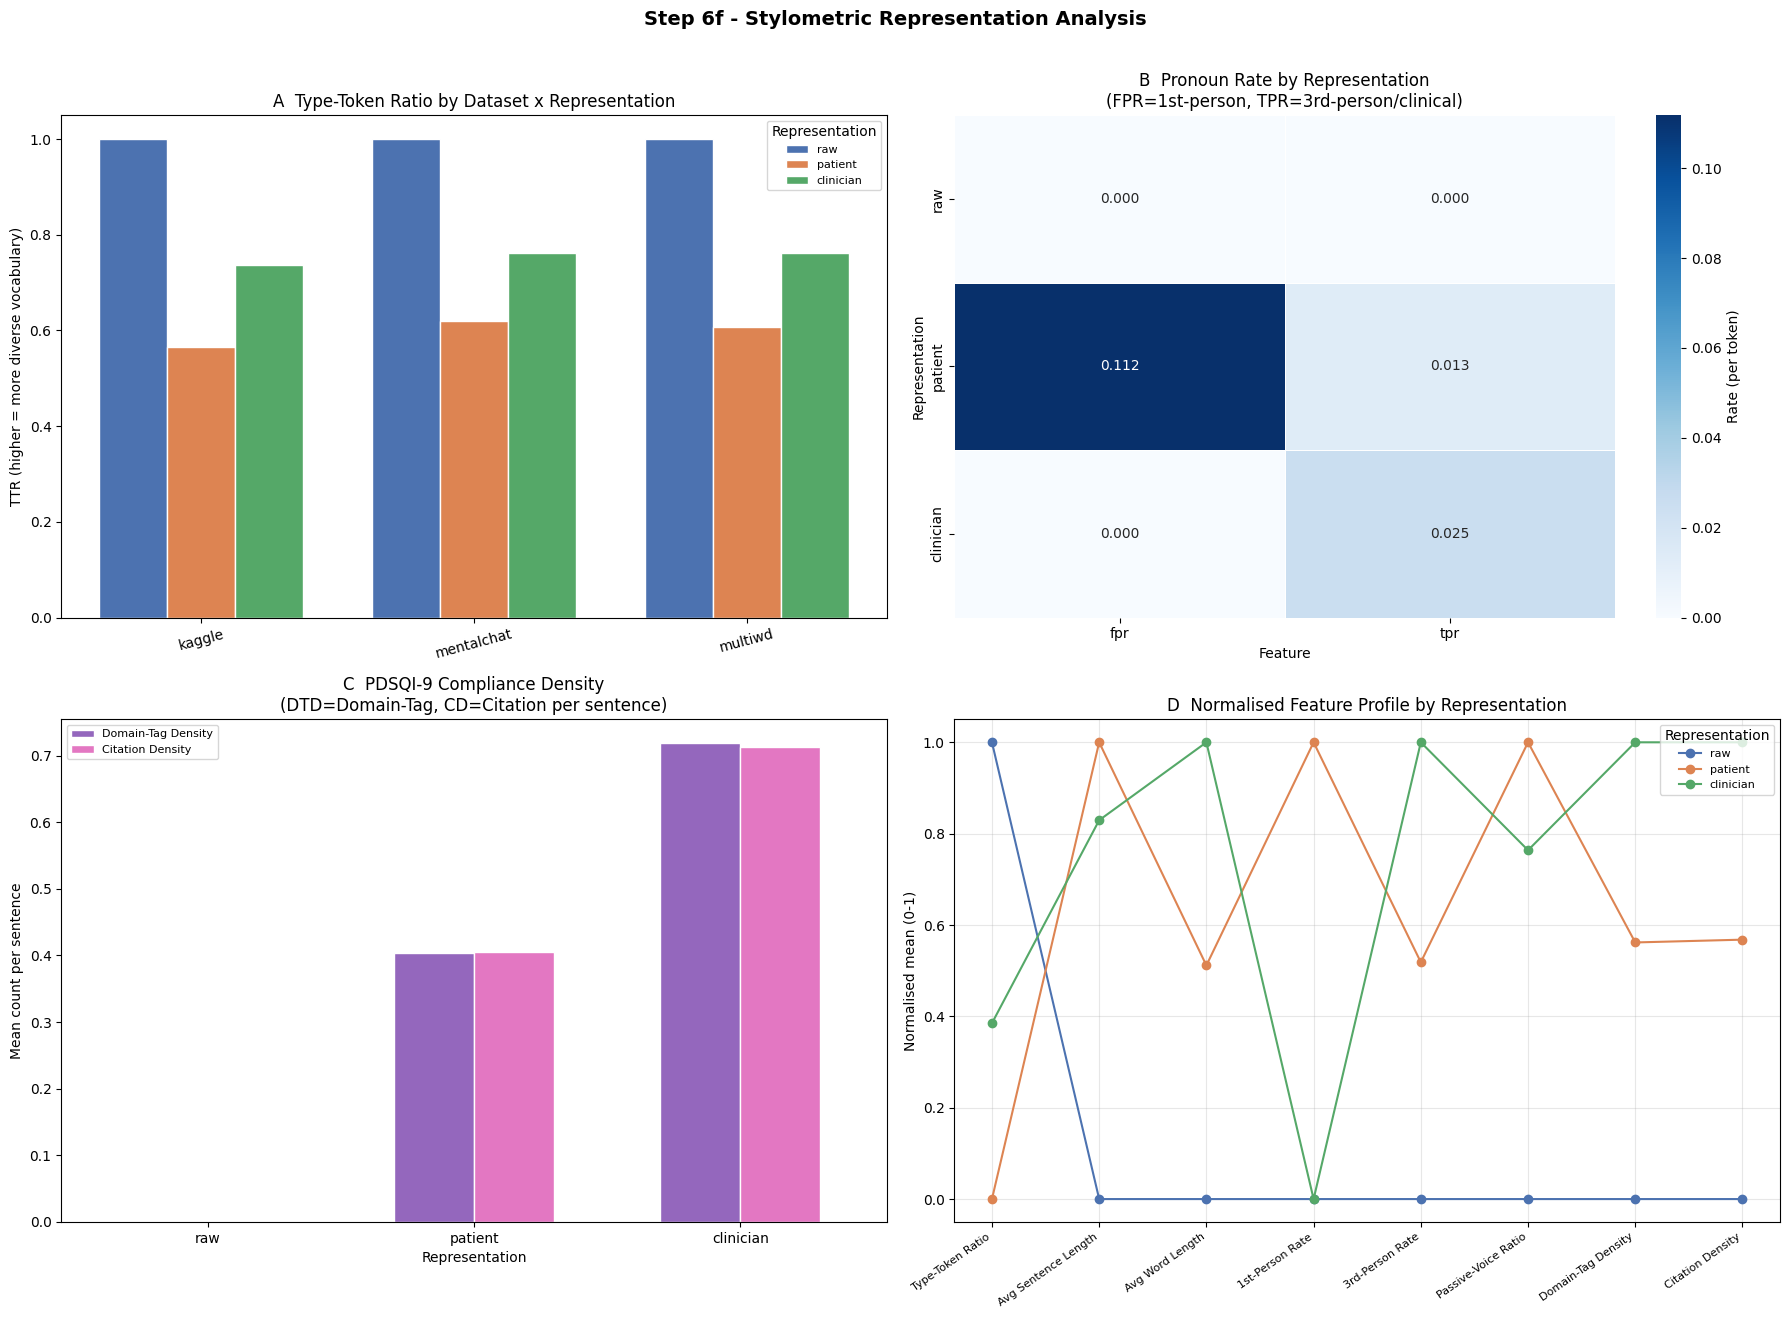

Saved dashboard: /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_step6_gold_eval/Val_Outputs_Annotated_v3_step6f_stylometric_dashboard.png


In [55]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

warnings.filterwarnings("ignore")

# constants inherited from Step 0c / Step 6a
# DRIVE_ROOT, ANNOT_XLSX, STEP6_DIR, MULTIWD_SHEET, MENTALCHAT_SHEET, KAGGLE_SHEET,
# GOLD, LABEL_COLS must already be defined.

STYLOMETRIC_COLS_TEXT = {
    "multiwd":    "rawtext",          # raw conversation column in the sheet
    "mentalchat": "rawtext",
    "kaggle":     "rawtext",
}
SUMMARY_COLS = {
    "patient":   "patientsummary",
    "clinician": "cliniciansummary",
}
SHEET_TO_KEY = {
    MULTIWD_SHEET:   "multiwd",
    MENTALCHAT_SHEET: "mentalchat",
    KAGGLE_SHEET:    "kaggle",
}

# ── RECONCILED with tutorial T-4d `stylometric_features` ────────────────────
# Adopts the tutorial's regex definitions, sentence splitter, rounding, and
# empty-text handling (returns 0.0 rather than NaN, no n_tokens key) so the
# feature values are directly comparable/reproducible against the tutorial's
# gold-standard numbers.
FP_RE   = re.compile(r"\b(I|me|my|mine|myself)\b", re.I)
TP_RE   = re.compile(r"\b(he|she|they|him|her|them|his|their)\b", re.I)
PASS_RE = re.compile(r"\b(is|are|was|were|be|been|being)\s+\w+ed\b", re.I)
TAG_RE  = re.compile(r"\[\w+\]")
CITE_RE = re.compile(r"\(Source[:\s].+?\)", re.I)

def stylometric_features(text):
    """Compute Garg et al. Table 2 stylometric features for a single text string."""
    if not text or not str(text).strip():
        return {k: 0.0 for k in ["ttr","asl","awl","fpr","tpr","pvr","dtd","cd"]}
    text = str(text)
    sents = [s.strip() for s in re.split(r"[.!?]", text) if s.strip()]
    words = re.findall(r"\b\w+\b", text.lower())
    ns, nw = max(len(sents), 1), max(len(words), 1)
    return {
        "ttr": round(len(set(words)) / nw, 4),
        "asl": round(nw / ns, 2),
        "awl": round(sum(len(w) for w in words) / nw, 2),
        "fpr": round(len(FP_RE.findall(text)) / nw, 4),
        "tpr": round(len(TP_RE.findall(text)) / nw, 4),
        "pvr": round(len(PASS_RE.findall(text)) / ns, 4),
        "dtd": round(len(TAG_RE.findall(text)) / ns, 4),
        "cd":  round(len(CITE_RE.findall(text)) / ns, 4),
    }

# ── load full annotated sheets ────────────────────────────────────────────────
records = []
for sheet, dskey in SHEET_TO_KEY.items():
    df = pd.read_excel(ANNOT_XLSX, sheet_name=sheet, engine="openpyxl")
    df.columns = [str(c).strip() for c in df.columns]

    # raw text
    raw_col = next((c for c in df.columns
                    if c.lower() in ("rawtext","text","raw","conversation",
                                     "dialogue","transcript","utterance")),
                   df.columns[0])
    for i, row in df.iterrows():
        feat = stylometric_features(row[raw_col])
        feat.update(dataset=dskey, representation="raw", row_index=i)
        records.append(feat)

    # patient / clinician summary columns
    for rep, col_hint in SUMMARY_COLS.items():
        col = next((c for c in df.columns if col_hint.lower() in c.lower()),
                   None)
        if col is None:
            # fallback: look for 'patient' or 'clinician' anywhere
            col = next((c for c in df.columns if rep in c.lower()), None)
        if col is None:
            continue
        for i, row in df.iterrows():
            feat = stylometric_features(row[col])
            feat.update(dataset=dskey, representation=rep, row_index=i)
            records.append(feat)

stylo_df = pd.DataFrame(records)

FEAT_COLS = ["ttr","asl","awl","fpr","tpr","pvr","dtd","cd"]
for c in FEAT_COLS:
    stylo_df[c] = pd.to_numeric(stylo_df[c], errors="coerce")

# ── save long-form CSV ────────────────────────────────────────────────────────
long_path = f"{STEP6_DIR}/Val_Outputs_Annotated_v3_step6f_stylometric_long.csv"
stylo_df.to_csv(long_path, index=False)
print(f"Saved long-form data: {long_path}  ({len(stylo_df)} rows)")

# ── summary: mean +/- std per dataset x representation ─────────────────────────
grp = stylo_df.groupby(["dataset","representation"])
summary_rows = []
for (ds, rep), g in grp:
    row = {"dataset": ds, "representation": rep}
    for c in FEAT_COLS:
        row[f"{c}_mean"] = round(g[c].mean(), 4)
        row[f"{c}_std"]  = round(g[c].std(),  4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
sum_path   = f"{STEP6_DIR}/Val_Outputs_Annotated_v3_step6f_stylometric_summary.csv"
summary_df.to_csv(sum_path, index=False)
print(f"Saved summary: {sum_path}")

# ── 4-panel diagnostic dashboard ─────────────────────────────────────────────
REPS   = ["raw","patient","clinician"]
PAL    = {"raw":"#4C72B0","patient":"#DD8452","clinician":"#55A868"}
LABELS = {"ttr":"Type-Token Ratio","asl":"Avg Sentence Length",
          "awl":"Avg Word Length","fpr":"1st-Person Rate",
          "tpr":"3rd-Person Rate","pvr":"Passive-Voice Ratio",
          "dtd":"Domain-Tag Density","cd":"Citation Density"}

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Step 6f - Stylometric Representation Analysis", fontsize=14,
             fontweight="bold", y=1.01)

# Panel A: TTR & ASL bar comparison across datasets x reps
ax = axes[0, 0]
pivot_ttr = (stylo_df.groupby(["dataset","representation"])["ttr"]
             .mean().unstack("representation").reindex(columns=REPS))
x   = np.arange(len(pivot_ttr))
w   = 0.25
for j, rep in enumerate(REPS):
    ax.bar(x + j*w, pivot_ttr[rep], w, label=rep,
           color=PAL[rep], edgecolor="white")
ax.set_xticks(x + w)
ax.set_xticklabels(pivot_ttr.index, rotation=15)
ax.set_title("A  Type-Token Ratio by Dataset x Representation")
ax.set_ylabel("TTR (higher = more diverse vocabulary)")
ax.legend(title="Representation", fontsize=8)

# Panel B: First-person vs Third-person rate heatmap
ax = axes[0, 1]
heat_data = (stylo_df[stylo_df["representation"].isin(REPS)]
             .groupby(["representation"])[["fpr","tpr"]]
             .mean().reindex(REPS))
sns.heatmap(heat_data, ax=ax, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label":"Rate (per token)"})
ax.set_title("B  Pronoun Rate by Representation\n(FPR=1st-person, TPR=3rd-person/clinical)")
ax.set_xlabel("Feature"); ax.set_ylabel("Representation")

# Panel C: PDSQI-9 compliance features (DTD & CD) per representation
ax = axes[1, 0]
pdsqi_features = ["dtd","cd"]
pf_data = (stylo_df.groupby("representation")[pdsqi_features]
           .mean().reindex(REPS))
pf_data.plot(kind="bar", ax=ax, width=0.6, edgecolor="white",
             color=["#9467BD","#E377C2"])
ax.set_title("C  PDSQI-9 Compliance Density\n(DTD=Domain-Tag, CD=Citation per sentence)")
ax.set_ylabel("Mean count per sentence")
ax.set_xlabel("Representation"); ax.tick_params(axis="x", rotation=0)
ax.legend(["Domain-Tag Density","Citation Density"], fontsize=8)

# Panel D: Radar-style mean features across reps (bar chart)
ax = axes[1, 1]
mean_feats = stylo_df.groupby("representation")[FEAT_COLS].mean().reindex(REPS)
# Normalise each feature 0-1 for comparability
norm = (mean_feats - mean_feats.min()) / (mean_feats.max() - mean_feats.min() + 1e-9)
x2   = np.arange(len(FEAT_COLS))
for j, rep in enumerate(REPS):
    ax.plot(x2, norm.loc[rep], marker="o", label=rep, color=list(PAL.values())[j])
ax.set_xticks(x2)
ax.set_xticklabels([LABELS.get(c,c) for c in FEAT_COLS],
                   rotation=35, ha="right", fontsize=8)
ax.set_title("D  Normalised Feature Profile by Representation")
ax.set_ylabel("Normalised mean (0-1)")
ax.legend(title="Representation", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = f"{STEP6_DIR}/Val_Outputs_Annotated_v3_step6f_stylometric_dashboard.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved dashboard: {plot_path}")

### Step 6g — Export Full Evaluation Report to Excel

Writes a consolidated `Step6_GoldEval_Report.xlsx` to Drive with one sheet per analysis.
This file is suitable for inclusion as a supplementary table in the paper.

In [56]:
# REPORT_PATH = f'{DRIVE_ROOT}/Step6_GoldEval_Report.xlsx'

# with pd.ExcelWriter(REPORT_PATH, engine='openpyxl') as writer:

#     # Sheet 1 — Gold label prevalence
#     gold_prev_rows = []
#     for ds_key, g in GOLD.items():
#         row = {'dataset': ds_key, 'n': len(g)}
#         row.update(g.mean().round(4).to_dict())
#         gold_prev_rows.append(row)
#     pd.DataFrame(gold_prev_rows).to_excel(writer, sheet_name='Gold_Prevalence', index=False)

#     # Sheet 2 — Per-domain F1 (wide)
#     domain_f1_cols = ['dataset', 'representation', 'backend'] + [f'{d}_f1' for d in LABEL_COLS]
#     metrics_df[domain_f1_cols].to_excel(writer, sheet_name='Per_Domain_F1', index=False)

#     # Sheet 3 — Aggregate metrics
#     agg_cols = ['dataset', 'representation', 'backend', 'micro_f1', 'macro_f1', 'precision', 'recall']
#     metrics_df[agg_cols].to_excel(writer, sheet_name='Aggregate_Metrics', index=False)

#     # Sheet 4 — Coverage gap (long)
#     gap_df.to_excel(writer, sheet_name='Coverage_Gap_Long', index=False)

#     # Sheet 5 — Coverage gap (pivot: domain × representation)
#     gap_pivot.round(4).reset_index().to_excel(writer, sheet_name='Coverage_Gap_Pivot', index=False)

#     # Sheet 6 — Representation fidelity matrix
#     fidelity_df.to_excel(writer, sheet_name='Fidelity_Matrix', index=False)

#     # Sheet 7 — Gold recall comparison (raw vs patient vs clinician)
#     recall_cmp.round(4).reset_index().to_excel(writer, sheet_name='Gold_Recall_By_Rep', index=False)

# print(f'\n✓ Step 6 evaluation report saved to: {REPORT_PATH}')
# print(f'  Sheets: Gold_Prevalence | Per_Domain_F1 | Aggregate_Metrics |')
# print(f'          Coverage_Gap_Long | Coverage_Gap_Pivot | Fidelity_Matrix | Gold_Recall_By_Rep')


In [57]:
import os
import pandas as pd

REPORTPATH = f"{DRIVE_ROOT}/Val_Outputs_Annotated_v3_Step6GoldEvalReport.xlsx"

with pd.ExcelWriter(REPORTPATH, engine="openpyxl") as writer:

    # Sheet 1: Gold label prevalence
    gold_prev_rows = []
    for dskey, g in GOLD.items():
        row = {"dataset": dskey, "n": len(g)}
        row.update(g.mean().round(4).to_dict())
        gold_prev_rows.append(row)
    pd.DataFrame(gold_prev_rows).to_excel(writer, sheet_name="Gold_Prevalence", index=False)

    # Sheet 2: Per-domain F1 (wide)
    domain_f1_cols = ["dataset","representation","backend"] + [f"{d}_f1" for d in LABEL_COLS]
    metrics_df[domain_f1_cols].to_excel(writer, sheet_name="Per_Domain_F1", index=False)

    # Sheet 3: Aggregate metrics
    agg_cols = ["dataset","representation","backend","micro_f1","macro_f1","precision","recall"]
    metrics_df[agg_cols].to_excel(writer, sheet_name="Aggregate_Metrics", index=False)

    # Sheet 4: Coverage gap (long)
    gap_df.to_excel(writer, sheet_name="Coverage_Gap_Long", index=False)

    # Sheet 5: Coverage gap pivot
    gap_pivot.round(4).reset_index().to_excel(writer, sheet_name="Coverage_Gap_Pivot", index=False)

    # Sheet 6: Representation fidelity matrix
    fidelity_df.to_excel(writer, sheet_name="Fidelity_Matrix", index=False)

    # Sheet 7: Gold recall by representation
    recall_cmp.round(4).reset_index().to_excel(writer, sheet_name="Gold_Recall_By_Rep", index=False)

    # Sheet 8: Stylometric summary (Step 6f)
    stylo_sum_path = f"{STEP6_DIR}/Val_Outputs_Annotated_v2_step6f_stylometric_summary.csv"
    if os.path.exists(stylo_sum_path):
        stylo_sum = pd.read_csv(stylo_sum_path)
        stylo_sum.to_excel(writer, sheet_name="Stylometrics", index=False)
        print("  + Sheet 'Stylometrics' added from Step 6f output")
    else:
        print("  WARNING: step6f_stylometric_summary.csv not found — run Step 6f first")

print(f"\nStep 6 evaluation report saved to {REPORTPATH}")
print("Sheets: Gold_Prevalence | Per_Domain_F1 | Aggregate_Metrics")
print("        Coverage_Gap_Long | Coverage_Gap_Pivot | Fidelity_Matrix")
print("        Gold_Recall_By_Rep | Stylometrics")


Step 6 evaluation report saved to /content/drive/MyDrive/Google Colab Notebooks/Datasets/Val_Outputs_Annotated_v3_Step6GoldEvalReport.xlsx
Sheets: Gold_Prevalence | Per_Domain_F1 | Aggregate_Metrics
        Coverage_Gap_Long | Coverage_Gap_Pivot | Fidelity_Matrix
        Gold_Recall_By_Rep | Stylometrics


EXTRA VALIDATION

In [58]:
import pandas as pd
import numpy as np

# Create a mapping of dataset names to their original raw dataframes
original_raw_dfs = {
    'multiwd': multiwd_df,
    'kaggle': kaggle_df,
    'mentalchat': mc_df
}

# Function to get the original raw text for a given row
def get_original_raw_text(row):
    dataset_name = row['dataset']
    original_idx = row['row_index'] # This is the iloc index used during validation
    if dataset_name in original_raw_dfs:
        source_df = original_raw_dfs[dataset_name]
        # Ensure the original_idx is within the bounds of the source_df
        if 0 <= original_idx < len(source_df):
            return source_df.loc[original_idx, 'text']
    return None

# Fix: Ensure failed_summaries is a true copy to avoid SettingWithCopyWarning
failed_summaries = val_df[val_df['pdsqi9_pass'] == False].copy()

# Add the 'raw_text' column to failed_summaries
failed_summaries.loc[:, 'raw_text'] = failed_summaries.apply(get_original_raw_text, axis=1)

synthesized_failed_texts = failed_summaries[failed_summaries['Synthesized'] < 3]['raw_text']
print("Raw text for summaries where 'Synthesized' score was less than 3:")
display(synthesized_failed_texts)

# Now get the raw text for passed summaries
passed_summaries = val_df[val_df['pdsqi9_pass'] == True].copy()
passed_summaries.loc[:, 'raw_text'] = passed_summaries.apply(get_original_raw_text, axis=1)

print("\nRaw text for summaries that passed all PDSQI-9 validation criteria:")
display(passed_summaries['raw_text'])


Raw text for summaries where 'Synthesized' score was less than 3:


,raw_text
31,I really hate myself. I dont know why but i fe...
40,I broke up with my toxic boyfriend today and h...
42,In new year¬¥s eve my family comes to my granf...
46,"So, hey. I'm coming to this sub because... I f..."
50,I wanna ask you because for some time now I've...
54,TLDR: only I can make myself happy again and I...
68,"Most of the time it‚Äôs the opposite, but some..."
70,For some reason time is going by too fast. May...
71,I hate myself so much It hurts I hate my body ...
72,I've been feeling disconnected from my partner...



Raw text for summaries that passed all PDSQI-9 validation criteria:


,raw_text
25,"I keep in phone contact with my parents, but s..."
36,When I am awake my anxiety is there every mome...
38,"Today, I barely ate anything at all. I had an ..."
76,"I appreciate your perspective, and I can see h..."
79,"Yes, I have. My mother currently relies on me ..."
82,I have mixed feelings about privacy when it co...
84,"I've been caring for my wife, who has Parkinso..."
88,I've reached an age where I find it hard to be...
90,"Thank you for your guidance and support, couns..."
120,I've been asked to focus on attitude today. Th...


### Comparison of Failed vs. Passed Summaries

Below is a side-by-side comparison of the raw texts for summaries that failed validation (specifically those with 'Synthesized' scores below 3) and summaries that passed all PDSQI-9 criteria. This can help identify patterns that lead to higher validation scores.

In [59]:
failed_df = synthesized_failed_texts.to_frame(name='Raw Text (Synthesized < 3)').reset_index(drop=True)
passed_df = passed_summaries['raw_text'].to_frame(name='Raw Text (All PDSQI-9 Passed)').reset_index(drop=True)

# Pad the shorter DataFrame with empty rows if necessary
max_len = max(len(failed_df), len(passed_df))
if len(failed_df) < max_len:
    failed_df = pd.concat([failed_df, pd.DataFrame([''] * (max_len - len(failed_df)), columns=failed_df.columns)], ignore_index=True)
if len(passed_df) < max_len:
    passed_df = pd.concat([passed_df, pd.DataFrame([''] * (max_len - len(passed_df)), columns=passed_df.columns)], ignore_index=True)

comparison_df = pd.concat([failed_df, passed_df], axis=1)
display(comparison_df)

,Raw Text (Synthesized < 3),Raw Text (All PDSQI-9 Passed)
0,I really hate myself. I dont know why but i fe...,"I keep in phone contact with my parents, but s..."
1,I broke up with my toxic boyfriend today and h...,When I am awake my anxiety is there every mome...
2,In new year¬¥s eve my family comes to my granf...,"Today, I barely ate anything at all. I had an ..."
3,"So, hey. I'm coming to this sub because... I f...","I appreciate your perspective, and I can see h..."
4,I wanna ask you because for some time now I've...,"Yes, I have. My mother currently relies on me ..."
5,TLDR: only I can make myself happy again and I...,I have mixed feelings about privacy when it co...
6,"Most of the time it‚Äôs the opposite, but some...","I've been caring for my wife, who has Parkinso..."
7,For some reason time is going by too fast. May...,I've reached an age where I find it hard to be...
8,I hate myself so much It hurts I hate my body ...,"Thank you for your guidance and support, couns..."
9,I've been feeling disconnected from my partner...,I've been asked to focus on attitude today. Th...


In [ ]:
import os
os.kill(os.getpid(), 9)